# Linear Regression on Cumulative Subscribers within the Personal Dataset

There is a very interesting graph on workshop item statistics only visible to mod authors, the cumulative subscribers chart.

![example](https://imgur.com/LgkOWxm.png)

It displays the amount of subscribers on a given day after the release of the workshop item (mod). Though the chart is sometimes messed up for some reason, displaying negative amount of subscribers, which is honestly a bit silly.

![example2](https://imgur.com/F4YHvKn.png)

In this notebook I will apply linear regression on my personal dataset on entries that are not messed up like the example above. With this I will try to figure out whether the thumbnail type has a say on subscriber retention over time. I will try to fit a line between data points on each individual thumbnail type and combine those lines on a final chart for analysis.

I will consider the first 60 days due to the limitation of my fairly recently released mod contained in the animated thumbnail category (Posted 22 Feb 2026).

# 1. Animated Thumbnails

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# ANIMATED THUMBNAILS
# stuff is not ordered
# this data is retrieved from line 804 on all saved mod HTML files
animated = {
  "Mod1" : [213,2880,3569,4068,4644,5172,6113,6403,6066,5964,5895,5847,5858,5953,5960,5869,5765,5794,5764,5796,5918,5880,5839,5864,5863,5866,5836,5927,5937,5875,5902,5929,5972,6059,6154,6138,6089,6055,6072,6123,6418,6870,7086,7201,7220,7317,7420,7570,7759,7656,7401,7432,7406,7396,7407,7592,7497,7409,7399,7436,7428,7481,7593,7567,7465,7557,7638,7718,7545],
  "Mod2" : [254,2858,4486,5455,6377,7481,9401,9566,9090,9093,9140,9212,9372,9528,9419,9355,9357,9428,9406,9488,9700,9583,9512,9442,9462,9454,9549,9657,9652,9474,9477,9506,9538,9601,9709,9697,9660,9693,9684,9724,9764,9821,9803,9754,9904,9860,9918,9925,10010,9998,9898,9928,9927,9944,9984,10120,10164,10185,10233,10212,10266,10267,10369,10446,10404,10411,10399,10491,10565,10636,10615,10581,10623,10671,10631,10708,10751,10760,10675,10739,10722,10710,10765,10842,10892,10809,10831,10864,10847,10934,10988,11008,10979,11004,11021,11045,11094,11186,11248,11160,11188,11262,11287,11313,11423,11437,11300,11305,11341,11348,11368,11473,11490,11417,11488,11455,11540,11516,11612,11622,11481,11544,11595,11550,11607,11729,11660,11610,11622,11638,11678,11695,11783,11727,11735,11686,11750,11787,11801,11824,11771,11754,11758,11756,11793,11814,11934,11942,11893,11889,11916,11939,11980,12047,12054,11978,12009,11996,12049,12094,12144,12140,12085,12166,12230,12243,12224,12267,12307,12253,12260,12294,12318,12298,12394,12385,12327,12379,12356,12433,12435,12523,12506,12407,12446,12436,12394,12412,12452,12456,12442,12411,12425,12494,12532,12645,12661,12629,12662,12662,12751,12729,12793,12792,12795,12805,12848,12868,12890,12925,12910,12852,12847,12857,12904,12906,12944,12911,12935,12888,12923,12931,13004,13047,13070,13065,13121,13122,13147,13150,13227,13292,13272,13270,13319,13322,13275,13314,13356,13383,13412,13412,13429,13429,13466,13516,13540,13516,13534,13547,13582,13636,13613,13636,13669,13698,13642,13704,13732,13769,13764,13735,13792,13785,13855,13838,13820,13753,13784,13805,13828,13787,13853,13879,13871,13890,13890,13881,13884,13932,13907,13900,13937,13954,13922,13936,13994,14006,14020,13997,14005,13989,14031,14100,14090,14043,14050,14063,14072,14049,14170,14123,14091,14081,14119,14081,14147,14226,14249,14158,14187,14171,14212,14213,14201,14230,14158,14143,14184,14192,14231,14305,14295,14244,14254,14244,14220,14233,14339,14289,14217,14233,14197,14153,14152,14230,14209,14128,14128,14143,14173,14213,14255,14267,14201,14286,14296,14283,14346,14391,14376,14329,14302,14328,14314,14384,14452,14507,14408,14428,14416,14411,14503,14607,14596,14493,14525,14503,14525,14659,14792,14752,14673,14652,14659,14688,14765,14769,14799,14684,14662,14675,14699,14755,14796,14845,14752,14741,14782,14769,14792,14876,14799,14746,14751,14763,14759,14788,14842,14879,14809,14794,14769,14827,14821,14877,14861,14859,14818,14834,14784,14799,14836,14845,14815,14830,14822,14755,14797,14858,14825,14705,14727,14761,14748,14777,14878,14851,15115,15388,15503,15621,15864,16073,16054,15987,15938,15957,16100,16528,16946,16966,16864,17039,17070,17088,17107,17255,17467,17259,17335,17441,17421,17502,17495,17500,17350,17353,17384,17374,17352,17470,17492,17330,17270,17315,17301,17337,17392,17337,17211,17181,17197,17202,17239,17353,17286,17243,17206,17213,17228,17251,17305,17348,17237,17220,17224,17233,17278,17350,17354,17305,17316,17302,17303,17389,17455,17429,17313,17329,17351,17372,17392,17502,17464,17420,17398,17422,17448,17473,17612,17559,17490,17517,17525,17490,17529,17583,17595,17537,17463,17489,17517,17523,17622,17568,17500,17512,17556,17579,17553,17641,17774,17742,17784,17813,17933,17976,18072,18008,17948,17919,17911,17965,17993,18059,17967,17879,17887,17909,17869,17961,17955,17959,17935,17942,18022,18136,18289,18637,18629,18671,18777,18859,18856,18894,18799,18852,18703,18685,18673,18660,18707,18728,18726,18720,18669,18634,18627,18636,18671,18668,18603,18658,18616,18574,18560,18611,18603,18543,18599,18581,18556,18536,18556,18578,18574,18556,18587,18519,18558,18600,18575,18548,18522,18531,18552,18751,19045,19150,19183,19285,19441,19553,19543,19502,19462,19509,19510,19528,19511,19467,19457,19485,19495,19533,19493,19448,19430,19465,19477,19459,19452,19435,19465,19486,19474,19509,19420,19396,19410,19409,19451,19483,19540,19450,19440,19417,19551,19804,19936,19999,19908,19880,19923,19912,19915,20102,20299,20092,20210,20268,20398,20616,20826,20893,20747,20753,20746,20695,20771,21038,21142,20944,20965,20960,21012,21129,21311,21232,21144,21223,21307,21286,21382,21403,21422,21298,21279,21355,21325,21336,21476,21422,21303,21236,21223,21231,21351,21405,21364,21179,21209,21238,21193,21255,21333,21329,21217,21235,21183,21192,21149,21164,21207,21165,21122,21097,21050,21123,21218,21164,21156,21086,21091,21105,21170,21264,21212,21130,21117,21102,21113,21165,21260,21214,21152,21094,21134,21097,21193,21236,21219,21129,21079,21114,21103,21138,21203,21138,21056,21092,21081,21049,21088,21170,21170,21063,21092,21099,21107,21205,21232,21184,21135,21089,21031,21003,21061,21058,21054,20969,21036,21006,21016,21023,21017,21032,20969,20977,20959,20992,21053,21071,21029,20951,20934,20959,20997,21043,21181,21256,21233,21285,21339,21361,21497,21596,21541,21394,21359,21336,21290,21352,21388,21380,21286,21267,21227,21238,21226,21312,21297,21178,21169,21196,21198,21205,21396,21431,21453,21361,21394,21454,21489,21577,21576,21510,21467,21446,21463,21512,21562,21608,21463,21478,21452,21464,21497,21595,21581,21514,21507,21472,21439,21515,21616,21524,21460,21435,21417,21411,21438,21470,21468,21393,21387,21388,21357,21418,21529,21525,21402,21391,21396,21347,21398,21433,21400,21421,21305,21316,21289,21311,21451,21253],
  "Mod3" : [916,2469,3183,4135,5241,6272,7021,6681,6631,6678,6810,7302,7773,7843,7794,7930,7986,7980,8047,8220,8419,8293,8370,8451,8437,8550,8562,8587,8473,8483,8517,8530,8510,8612,8602,8509,8460,8509,8473,8520,8591,8554,8466,8476,8477,8486,8517,8591,8567,8538,8522,8548,8530,8598,8636,8639,8593,8582,8562,8564,8600,8674,8688,8658,8645,8649,8661,8744,8798,8770,8699,8708,8737,8758,8770,8856,8845,8814,8818,8859,8920,9001,9125,9114,9056,9081,9106,9083,9163,9215,9251,9239,9212,9222,9264,9281,9390,9359,9292,9327,9363,9378,9384,9468,9501,9429,9433,9447,9491,9496,9595,9600,9570,9578,9597,9606,9641,9731,9698,9590,9654,9692,9693,9764,9773,9813,9797,9817,9865,9863,9882,9954,9989,9959,9994,10020,10075,10105,10110,10212,10123,10136,10182,10194,10232,10310,10296,10307,10284,10289,10313,10369,10398,10422,10401,10444,10458,10404,10410,10488,10481,10444,10499,10489,10495,10486,10518,10531,10581,10545,10583,10565,10572,10632,10656,10644,10641,10681,10710,10918,11252,11327,11397,11522,11680,11788,11831,11862,11779,11866,11896,11931,11910,11904,11903,11932,11936,11995,11985,11967,11952,11992,12011,12007,12006,12017,12027,12083,12059,12095,11985,11963,12003,12005,12069,12094,12137,12085,12111,12110,12229,12509,12598,12631,12605,12609,12621,12650,12616,12871,13050,12844,12975,13004,13115,13339,13561,13643,13544,13550,13572,13522,13582,13843,13957,13801,13823,13828,13899,13983,14148,14105,14050,14131,14216,14209,14264,14292,14321,14261,14227,14325,14302,14317,14465,14438,14323,14275,14283,14274,14386,14469,14417,14249,14294,14296,14267,14341,14415,14410,14300,14338,14278,14291,14253,14272,14306,14282,14245,14241,14181,14252,14343,14312,14300,14246,14275,14281,14353,14444,14396,14344,14336,14317,14340,14396,14463,14398,14392,14365,14392,14389,14460,14513,14487,14415,14390,14417,14396,14462,14499,14468,14398,14430,14414,14388,14393,14500,14487,14404,14424,14426,14436,14545,14566,14551,14483,14455,14425,14406,14442,14434,14443,14378,14449,14367,14428,14418,14426,14432,14425,14398,14404,14432,14460,14507,14474,14393,14368,14416,14441,14530,14614,14700,14675,14763,14843,14839,14961,15063,15035,14896,14877,14848,14814,14834,14867,14883,14831,14799,14785,14776,14757,14849,14829,14730,14735,14756,14764,14759,14945,14978,15018,14925,14979,15002,15008,15095,15102,15019,15023,15004,14999,15041,15120,15162,15035,15048,15042,15087,15052,15172,15154,15088,15058,15032,15047,15109,15182,15095,15062,15045,15022,15029,15034,15079,15090,15024,15024,14998,14992,15043,15153,15161,15042,15005,15028,14970,15013,15044,15033,15040,14977,14980,14961,14971,15067,14911],
  "Mod4" : [811,2072,2977,3810,3816,4047,4377,4299,4337,4596,4859,4734,4846,4942,5123,5403,5648,5773,5697,5738,5790,5808,5865,6166,6332,6228,6268,6310,6371,6500,6645,6651,6606,6709,6795,6865,6922,7036,7059,7048,7015,7111,7112,7147,7236,7276,7204,7168,7184,7185,7263,7340,7314,7230,7266,7278,7274,7329,7399,7416,7331,7362,7366,7338,7336,7347,7420,7388,7370,7386,7325,7419,7464,7448,7471,7436,7462,7474,7574,7659,7661,7633,7628,7611,7701,7736,7802,7797,7794,7745,7792,7821,7907,7989,7951,7902,7901,7932,7942,7977,8041,8031,8022,8071,8038,8021,8088,8204,8160,8110,8150,8150,8199,8269,8277,8267,8258,8240,8208,8213,8245,8232,8278,8247,8350,8306,8351,8341,8358,8355,8340,8351,8367,8385,8458,8490,8480,8433,8477,8493,8509,8592,8710,8801,8813,8892,8961,8984,9099,9233,9172,9071,9050,9046,9031,9089,9098,9126,9089,9080,9086,9119,9118,9178,9180,9098,9145,9133,9133,9154,9320,9393,9417,9348,9432,9458,9484,9578,9586,9506,9501,9494,9531,9540,9629,9660,9561,9596,9582,9631,9619,9673,9672,9652,9635,9628,9627,9647,9728,9679,9666,9676,9642,9652,9671,9723,9745,9719,9700,9682,9671,9731,9832,9869,9744,9756,9786,9760,9791,9807,9809,9824,9773,9796,9798,9820,9879,9736],
  "Mod5" : [597,1840,2108,2564,2928,3484,4152,4421,4576,4481,4536,4583,4622,4697,4989,5134,5066,5115,5182,5247,5357,5502,5512,5471,5589,5668,5706,5764,5852,5902,5886,5892,5983,6015,6040,6129,6149,6097,6068,6060,6070,6142,6234,6219,6111,6161,6178,6171,6222,6289,6312,6223,6256,6254,6243,6253,6259,6331,6289,6265,6286,6241,6317,6371,6350,6374,6345,6379,6393,6476,6554,6567,6540,6539,6518,6591,6625,6723,6706,6724,6678,6726,6752,6820,6887,6859,6825,6816,6849,6856,6892,6965,6942,6944,6997,6985,6985,7005,7124,7092,7072,7087,7092,7150,7221,7228,7229,7191,7192,7139,7167,7198,7185,7222,7168,7259,7217,7251,7235,7293,7312,7291,7298,7304,7305,7372,7421,7382,7344,7360,7388,7416,7493,7606,7669,7719,7812,7885,7908,8036,8146,8073,8000,8011,8007,7977,8034,8044,8064,8037,8024,8042,8065,8073,8140,8137,8057,8080,8093,8097,8120,8239,8323,8356,8309,8373,8404,8420,8508,8538,8445,8457,8461,8483,8491,8563,8594,8510,8537,8545,8589,8573,8616,8653,8611,8620,8596,8613,8647,8732,8716,8678,8684,8656,8665,8695,8749,8758,8757,8730,8724,8714,8751,8883,8908,8811,8818,8839,8814,8820,8834,8852,8891,8822,8855,8854,8857,8918,8780],
  "Mod6" : [739,1553,1958,2186,2716,3088,3398,3429,3610,3659,3664,3692,3791,3816,3908,3992,4038,3969,3980,3989,4000,4098,4205,4194,4125,4157,4187,4191,4260,4295,4321,4261,4304,4306,4314,4303,4330,4402,4393,4383,4397,4344,4434,4486,4480,4507,4474,4498,4560,4647,4742,4768,4757,4778,4763,4835,4876,4949,4920,4963,4952,5007,5011,5103,5159,5147,5114,5114,5154,5170,5227,5306,5269,5279,5301,5309,5306,5344,5454,5453,5442,5463,5482,5534,5611,5633,5646,5603,5599,5578,5594,5616,5631,5694,5619,5707,5696,5751,5770,5794,5822,5787,5805,5824,5846,5886,5934,5937,5885,5896,5918,5956,6031,6133,6186,6246,6354,6417,6413,6530,6679,6624,6545,6558,6553,6534,6586,6594,6626,6589,6573,6572,6619,6612,6704,6697,6645,6667,6678,6681,6698,6846,6908,6947,6903,6972,7030,7050,7127,7151,7047,7069,7061,7096,7100,7179,7236,7150,7161,7154,7212,7199,7259,7286,7287,7266,7247,7264,7290,7377,7353,7343,7319,7296,7302,7340,7373,7419,7384,7371,7355,7354,7401,7524,7552,7468,7463,7480,7450,7463,7483,7473,7498,7464,7483,7477,7488,7538,7424],
  "Mod7" : [377,1730,2770,3621,3706,4081,4329,4463,4592,4922,5113,5051,5124,5183,5255,5368,5565,5654,5586,5690,5796,5857,5902,5984,6021,5996,5985,6077,6116,6177,6243,6293,6235,6197,6187,6190,6284,6362,6371,6264,6306,6339,6338,6407,6443,6471,6396,6431,6430,6429,6433,6442,6522,6464,6456,6471,6438,6508,6587,6541,6595,6549,6554,6604,6681,6763,6785,6748,6756,6743,6819,6850,6921,6910,6900,6869,6911,6926,6985,7073,7070,7036,7019,7069,7081,7106,7186,7158,7153,7164,7164,7164,7193,7332,7284,7245,7254,7289,7336,7400,7419,7410,7388,7381,7380,7373,7394,7403,7430,7380,7482,7421,7454,7474,7525,7531,7514,7519,7558,7552,7612,7625,7631,7578,7597,7620,7654,7724,7849,7922,7966,8042,8111,8130,8221,8373,8333,8266,8258,8248,8214,8261,8280,8293,8278,8257,8274,8290,8299,8375,8390,8318,8325,8346,8363,8374,8532,8581,8619,8542,8614,8669,8689,8776,8787,8713,8719,8706,8720,8753,8821,8858,8751,8780,8791,8819,8817,8872,8895,8856,8858,8844,8852,8894,8985,8931,8925,8923,8891,8882,8919,8982,8990,8961,8952,8928,8933,8968,9082,9119,9006,9004,9031,8992,9002,9040,9040,9086,9016,9047,9047,9053,9106,8977],
  "Mod8" : [471,1791,2556,2778,3069,3396,3813,4005,4252,4351,4314,4462,4627,4700,4810,4900,4938,4907,4923,5032,5045,5099,5192,5243,5193,5188,5189,5175,5293,5388,5407,5299,5311,5331,5331,5397,5458,5478,5418,5459,5458,5458,5479,5485,5557,5522,5516,5511,5478,5554,5627,5604,5638,5591,5625,5659,5737,5809,5822,5789,5782,5784,5840,5879,5937,5936,5952,5910,5943,5979,6033,6102,6090,6070,6049,6098,6118,6148,6214,6183,6190,6204,6216,6225,6242,6368,6330,6325,6336,6335,6391,6481,6497,6498,6470,6465,6424,6434,6450,6482,6509,6462,6532,6505,6532,6538,6601,6606,6617,6607,6645,6633,6685,6732,6719,6698,6696,6725,6752,6802,6916,6987,7030,7125,7174,7188,7288,7455,7370,7324,7328,7343,7300,7359,7388,7401,7369,7365,7367,7405,7413,7490,7463,7405,7415,7450,7456,7481,7615,7652,7699,7624,7705,7743,7757,7821,7870,7773,7776,7771,7791,7794,7870,7926,7816,7837,7838,7881,7868,7895,7941,7935,7933,7918,7938,7982,8060,8031,8020,8011,7992,8005,8013,8059,8070,8067,8028,8031,8005,8060,8172,8186,8113,8104,8124,8091,8079,8128,8105,8167,8101,8132,8128,8138,8203,8075],
  "Mod9" : [3,560,2743,4071,5330,6510,7438,8416,8574,8526,8652,8793,9052,9322,9591,9752,9966,10160,10346,10523,10657,10848,10958,11129,11241,11437,11578,11785,12404,12694,12865,13304,13462,13654,13912,13933,14083,14214,14277,14592,14819,15055,15130,15256,15441,15528,15648,15765,15776,15900,15970,16016,16108,16325,16413,16557,16661,16700,16707,16872,16925,16933,16966,17111,17185,17206,17255,17288,17419,17441,17536,17774,17808,17833,17869,17997,18073,18249,18223,18125,18126,18152,18242,18392,18506,18574,18452,18466,18504,18572,18606,18754,18818,18714,18709,18803,18845,18954,19067,19191,19077,19040,19066,19168,19223,19392,19331,19231,19246,19323,19391,19465,19565,19632,19564,19577,19587,19682,19748,19965,19963,19791,19844,19901,19929,20035,20225,20381,20227,20262,20264,20333,20425,20508,20567,20443,20469,20558,20547,20579,20754,20766,20628,20676,20677,20690,20780,21024,20999,20823,20861,20923,20868,21026,21137,21234,21913,22322,22454,22715,23000,23361,23494,23260,23288,23439,23502,23629,23937,23837,23727,23696,23730,23753,23855,24112,23992,23845,23793,23773,23809,23984,24061,24168,23849,23875,23873,23931,24039,24342,24273,24187,24207,24276,24297,24425,24484,24373,24374,24465,24472,24551,24582,24721,24683,24512,24498,24528,24516,24652,24899,24962,24860,24885,24815,24877,24969,25093,25092,25020,25078,25015,25101,25237,25428,25418,25255,25261,25339,25280,25421,25585,25614,25417,25442,25468,25434,25488,25630,25717,25579,25578,25612,25668,25782,25931,25939,25883,25884,25863,25955,26046,26230,26335,26148,26223,26241,26352,26519,26703,26740,26454,26427,26482,26524,26612,26793,26824,26698,26707,26725,26934,26981,27192,27181,26987,27039,27081,27035,27150,27409,27427,27342,27301,27345,27434,27455,27551,27539,27486,27383,27463,27482,27510,27532,27466,27366,27384,27350,27444,27478,27686,27722,27586,27585,27577,27641,27709,27846,27866,27725,27746,27782,27826,27925,28086,28111,27998,28098,28214,28188,28177,28280,28313,28167,28171,28267,28271,28319,28510,28491,28365,28467,28453,28570,28604,28751,28730,28626,28611,28674,28593,28690,28786,28786,28690,28668,28699,28785,28829,29025,29064,29075,29132,29204,29242,29294,29383,29391,29376,29331,29352,29408,29459,29475,29462,29377,29373,29474,29500,29471,29501,29472,29423,29417,29433,29473,29533,29574,29678,29692,29764,29762,29754,29816,29907,30001,30021,30002,30094,30158,30093,30198,30234,30252,30291,30301,30325,30388,30513,30593,30666,30584,30647,30629,30653,30811,30777,30768,30846,30969,30918,31038,31031,31085,31103,31073,31077,31109,31158,31124,31096,31070,31087,31057,31138,31189,31253,31406,31352,31350,31365,31335,31316,31474,31447,31404,31494,31505,31454,31428,31520,31533,31517,31458,31494,31466,31528,31689,31669,31512,31548,31565,31576,31616,31852,31861,31738,31707,31725,31682,31824,31956,31994,31772,31785,31793,31848,31895,31971,31956,31845,31895,31927,31895,31966,32085,32103,31993,31982,31983,31995,32035,32204,32172,32051,32017,32007,31955,32000,32163,32113,31952,31962,32021,32050,32157,32268,32256,32121,32179,32223,32281,32380,32490,32513,32373,32390,32415,32370,32461,32590,32717,32542,32587,32496,32534,32680,32940,33028,32836,32891,32881,32904,33109,33377,33294,33104,33089,33198,33190,33347,33473,33514,33271,33258,33264,33291,33377,33544,33551,33475,33358,33384,33482,33519,33699,33590,33545,33523,33568,33588,33727,33859,33862,33779,33794,33732,33853,33889,34034,34102,34175,34297,34367,34374,34473,34464,34476,34411,34409,34466,34423,34430,34645,34657,34417,34464,34501,34563,34580,34797,34799,34979,35136,35242,35462,35646,36016,36038,35942,35856,35874,36017,36477,36983,36937,36768,36948,36979,36977,37043,37257,37511,37211,37269,37382,37382,37507,37597,37594,37435,37369,37415,37403,37395,37589,37576,37407,37344,37464,37420,37529,37685,37670,37451,37453,37475,37456,37543,37716,37656,37539,37481,37512,37576,37632,37743,37749,37553,37513,37541,37587,37667,37829,37862,37725,37739,37734,37749,37843,37963,37925,37786,37781,37812,37869,37956,38132,38110,37956,37977,38037,38096,38174,38424,38328,38186,38258,38265,38273,38340,38434,38527,38411,38314,38358,38388,38424,38595,38611,38479,38402,38513,38634,38563,38732,38853,38725,38777,38815,38998,39105,39258,39194,39077,39043,39077,39069,39146,39293,39176,38997,39005,39036,39024,39178,39222,39307,39215,39264,39375,39532,39679,40044,40100,40056,40180,40273,40262,40319,40258,40323,40174,40140,40164,40115,40214,40301,40308,40293,40253,40243,40250,40260,40287,40270,40197,40234,40198,40171,40138,40206,40270,40241,40268,40291,40264,40188,40267,40258,40279,40337,40310,40245,40221,40319,40314,40270,40312,40333,40348,40527,40830,40971,41033,41103,41263,41477,41417,41381,41376,41496,41483,41494,41486,41504,41451,41508,41471,41553,41491,41497,41533,41538,41540,41613,41581,41628,41624,41630,41704,41794,41657,41636,41667,41678,41778,41906,42011,41908,41846,41904,41968,42272,42416,42442,42376,42259,42330,42328,42391,42670,42858,42563,42649,42682,42841,43054,43350,43415,43198,43197,43198,43163,43264,43619,43717,43431,43471,43514,43534,43670,43912,43875,43709,43866,43966,43952,44062,44149,44186,44035,44013,44125,44100,44146,44339,44340,44166,44042,44091,44064,44211,44364,44378,44117,44187,44179,44147,44277,44392,44402,44187,44207,44111,44090,44111,44142,44212,44016,43986,43970,43942,44019,44234,44180,44103,44036,44000,44060,44141,44429,44396,44188,44195,44142,44253,44329,44556,44410,44295,44231,44322,44316,44465,44515,44528,44291,44271,44296,44282,44306,44480,44494,44316,44354,44339,44366,44385,44605,44610,44382,44405,44452,44414,44586,44761,44704,44642,44648,44470,44497,44579,44625,44630,44505,44637,44623,44659,44734,44763,44761,44714,44713,44665,44748,44904,45032,45080,44842,44795,44896,44952,45120,45253,45385,45284,45295,45366,45377,45555,45747,45671,45486,45434,45440,45386,45421,45486,45490,45340,45283,45253,45300,45310,45456,45467,45281,45265,45317,45266,45332,45618,45601,45626,45497,45523,45594,45644,45804,45864,45723,45712,45677,45725,45842,45985,45998,45828,45812,45788,45873,45961,46098,46114,45990,45949,45913,45899,45941,46195,46141,45957,45945,45938,45935,46013,46116,46133,46004,45961,45955,45984,46149,46311,46296,46095,46101,46188,46067,46197,46324,46231,46274,46120,46133,46127,46150,46364,45999],
  "Mod10" : [149,2298,3510,4412,5274,5790,6382,6793,6943,7066,7049,7131,7267,7364,7412,7476,7468,7555,7611,7613,7631,7651,7698,7713,7687,7733,7791,7834,7872,7944,7969,7959,8004,8010,8066,8039,8093,8134,8071,8087,8132,8146,8146,8198,8303,8277,8317,8339,8384,8432,8517,8505,8475,8478,8500,8518,8577,8596,8639,8598,8609,8632,8637,8682,8715,8802,8739,8750,8766,8766,8832,8881,8920,8910,8885,8910,8943,8973,9031,9024,8947,8978,9021,9061,9132,9155,9148,9146,9150,9178,9198,9238,9272,9252,9159,9198,9213,9193,9258,9285,9367,9285,9254,9248,9282,9314,9353,9348,9293,9318,9337,9374,9382,9414,9392,9377,9433,9415,9432,9475,9561,9529,9473,9509,9531,9526,9577,9660,9713,10471,10878,10998,11200,11458,11714,11812,11672,11669,11710,11759,11808,11873,11799,11742,11744,11764,11733,11773,11942,11867,11784,11710,11720,11705,11788,11844,11812,11670,11675,11672,11683,11731,11800,11731,11696,11710,11728,11734,11775,11756,11740,11716,11813,11806,11828,11820,11872,11817,11764,11784,11786,11775,11830,11921,11966,11938,11971,11940,12009,12035,12098,12102,12062,12079,12046,12116,12186,12258,12222,12155,12182,12225,12165,12226,12246,12254,12165,12223,12188,12163,12227,12273,12270,12203,12226,12244,12217,12305,12336,12362,12332,12342,12341,12389,12404,12503,12543,12433,12464,12489,12530,12562,12638,12683,12537,12512,12532,12518,12574,12639,12647,12573,12631,12597,12663,12650,12702,12699,12572,12603,12661,12611,12626,12738,12710,12656,12665,12680,12720,12707,12764,12728,12719,12635,12694,12703,12708,12718,12657,12648,12646,12651,12693,12706,12797,12786,12758,12751,12786,12807,12828,12898,12909,12833,12815,12840,12884,12914,12938,12955,12903,12982,13013,13028,13000,13031,13064,12998,13001,13024,13040,13029,13133,13105,13046,13121,13112,13173,13171,13249,13216,13138,13183,13161,13101,13116,13143,13144,13102,13087,13095,13156,13201,13290,13302,13281,13313,13312,13358,13356,13428,13425,13446,13425,13481,13441,13467,13485,13479,13432,13451,13434,13460,13455,13532,13486,13497,13479,13529,13498,13609,13610,13646,13643,13688,13662,13654,13679,13759,13787,13770,13760,13772,13810,13752,13775,13824,13831,13862,13873,13877,13894,13920,13958,13953,13948,13948,13944,14001,14057,14043,14055,14062,14106,14071,14121,14126,14157,14168,14126,14170,14198,14232,14220,14203,14059,14202,14108,14145,14137,14160,14126,14146,14152,14108,14138,14208,14206,14078,14089,14137,14142,14138,14248,14208,14425,14656,14753,14917,15124,15360,15378,15324,15268,15285,15421,15848,16263,16278,16181,16343,16355,16376,16370,16536,16758,16541,16609,16708,16689,16777,16757,16779,16647,16606,16646,16640,16623,16762,16752,16611,16552,16611,16566,16618,16659,16629,16486,16471,16473,16503,16522,16637,16581,16536,16490,16496,16497,16500,16557,16576,16495,16486,16474,16465,16504,16581,16587,16536,16541,16529,16540,16605,16661,16651,16543,16562,16588,16591,16622,16706,16693,16625,16619,16651,16684,16710,16829,16774,16708,16727,16724,16694,16746,16769,16810,16767,16689,16712,16757,16713,16818,16783,16725,16711,16756,16767,16762,16810,16818,16736,16726,16726,16757,16757,16854,16797,16721,16717,16730,16732,16759,16813,16762,16672,16694,16732,16701,16789,16752,16791,16750,16741,16768,16766,16787,16828,16865,16769,16811,16829,16831,16867,16874,16952,16852,16849,16866,16848,16911,16944,16898,16904,16860,16858,16870,16894,16934,16918,16880,16922,16891,16840,16845,16906,16909,16855,16878,16846,16830,16793,16814,16818,16852,16840,16832,16790,16819,16858,16840,16812,16812,16830,16841,17006,17278,17401,17427,17529,17674,17771,17772,17760,17721,17764,17768,17777,17747,17733,17731,17730,17708,17761,17705,17690,17668,17709,17698,17690,17679,17672,17704,17705,17702,17737,17635,17610,17653,17635,17690,17711,17768,17709,17678,17682,17787,18046,18103,18171,18112,18080,18104,18131,18107,18312,18515,18306,18421,18451,18562,18782,18975,19044,18907,18899,18916,18865,18945,19202,19266,19104,19109,19124,19161,19222,19439,19385,19280,19381,19442,19433,19502,19522,19528,19439,19397,19477,19451,19468,19568,19539,19433,19396,19374,19386,19472,19551,19515,19322,19349,19357,19325,19386,19453,19442,19331,19355,19290,19307,19253,19289,19335,19279,19219,19195,19159,19215,19317,19265,19232,19171,19188,19177,19240,19321,19280,19213,19182,19188,19195,19237,19319,19250,19219,19190,19223,19185,19250,19295,19255,19188,19120,19149,19158,19173,19224,19180,19083,19140,19090,19077,19110,19196,19199,19095,19117,19103,19132,19191,19240,19186,19139,19086,19050,19024,19066,19034,19030,18955,19020,18981,19024,19017,19012,19012,18953,18961,18922,18969,19028,19003,18958,18877,18857,18862,18911,18965,19067,19162,19122,19173,19231,19233,19337,19431,19380,19255,19236,19212,19188,19235,19247,19243,19165,19121,19133,19144,19123,19173,19165,19084,19065,19082,19090,19104,19274,19297,19299,19227,19275,19291,19331,19394,19361,19297,19276,19258,19260,19282,19363,19397,19271,19276,19267,19284,19292,19340,19348,19311,19290,19263,19264,19316,19384,19315,19259,19245,19244,19230,19245,19245,19280,19198,19178,19185,19152,19229,19323,19299,19179,19183,19188,19129,19159,19230,19209,19237,19156,19148,19134,19140,19215,19063],
  "Mod11" : [706,2617,4549,5264,5668,6431,6856,6868,6991,7259,7435,7291,7390,7515,7520,7663,7707,7733,7634,7635,7684,7692,7680,7814,7782,7656,7606,7671,7657,7694,7797,7725,7645,7634,7643,7661,7715,7799,7766,7745,7734,7788,7776,7828,7885,7912,7867,7845,7818,7856,7901,7982,8002,7975,8000,8016,8011,8092,8150,8153,8101,8099,8147,8155,8181,8257,8298,8274,8303,8346,8459,8554,8716,8728,8672,8739,8811,8793,8899,8949,8991,8984,8943,8991,9034,9093,9228,9216,9177,9209,9232,9307,9287,9373,9423,9376,9389,9392,9492,9517,9642,9665,9632,9685,9685,9744,9763,9857,9855,9757,9815,9857,9898,9995,10001,10055,10058,10088,10171,10174,10200,10304,10337,10339,10343,10431,10463,10540,10617,10699,10654,10667,10694,10718,10791,10857,10898,10944,10948,10903,10957,11041,11074,11055,11065,11105,11151,11089,11141,11196,11218,11185,11217,11254,11285,11270,11331,11346,11419,11393,11451,11396,11435,11519,11542,11532,11551,11599,11620,11786,12124,12271,12373,12497,12719,12814,12872,12915,12896,12938,12948,13013,13050,13046,13101,13128,13118,13178,13193,13188,13189,13278,13272,13287,13267,13310,13314,13416,13410,13451,13351,13363,13400,13389,13437,13504,13598,13517,13507,13489,13638,13923,14061,14134,14084,14095,14129,14174,14178,14406,14562,14362,14506,14598,14705,14952,15173,15286,15186,15154,15206,15150,15225,15527,15610,15426,15464,15484,15543,15676,15880,15857,15763,15861,15963,15949,15998,16068,16122,16021,16018,16106,16115,16078,16239,16232,16126,16053,16076,16078,16210,16282,16255,16092,16130,16158,16125,16214,16304,16311,16185,16209,16165,16199,16156,16197,16292,16191,16158,16152,16116,16194,16287,16238,16212,16136,16162,16198,16304,16392,16346,16297,16247,16253,16275,16345,16453,16423,16375,16360,16390,16419,16488,16552,16542,16454,16433,16447,16487,16492,16603,16573,16504,16536,16531,16513,16551,16705,16673,16583,16575,16594,16628,16740,16800,16755,16706,16714,16696,16737,17122,17527,17555,17514,17531,17481,17560,17648,17680,17733,17671,17643,17630,17704,17817,17942,17956,17880,17854,17964,18033,18157,18326,18393,18304,18438,18551,18561,18783,18884,18837,18723,18682,18683,18660,18726,18810,18827,18671,18673,18708,18689,18707,18840,18821,18726,18745,18781,18837,18889,19138,19160,19141,19070,19117,19208,19265,19393,19366,19274,19216,19154,19184,19264,19391,19493,19332,19349,19313,19371,19344,19476,19488,19383,19365,19326,19322,19388,19531,19442,19440,19374,19367,19350,19427,19427,19442,19370,19390,19325,19334,19428,19614,19523,19365,19375,19407,19408,19405,19502,19467,19454,19389,19378,19367,19426,19556,19309],
  "Mod12" : [666,2044,2432,2943,3514,3833,4300,4380,4412,4352,4344,4413,4469,4470,4585,4553,4466,4446,4502,4493,4518,4578,4506,4476,4486,4495,4522,4535,4607,4605,4605,4606,4641,4657,4712,4743,4772,4755,4760,4750,4787,4824,4903,4918,4916,4950,4939,4969,5035,5110,5111,5076,5110,5143,5181,5206,5273,5330,5288,5285,5327,5397,5508,5640,5668,5634,5690,5721,5720,5783,5828,5843,5852,5820,5836,5876,5918,5993,6025,6000,6027,6080,6106,6108,6177,6224,6183,6186,6197,6254,6266,6339,6360,6361,6370,6386,6418,6436,6507,6503,6437,6454,6508,6499,6578,6617,6615,6618,6650,6674,6678,6706,6759,6782,6769,6795,6844,6879,6893,6940,6992,6940,6960,6973,6998,7045,7099,7110,7144,7159,7139,7179,7201,7229,7257,7252,7307,7341,7283,7305,7385,7395,7368,7398,7418,7439,7420,7464,7491,7532,7494,7541,7506,7535,7618,7629,7610,7614,7667,7703,7879,8182,8316,8443,8551,8770,8911,8945,9041,8938,8995,9008,9043,9028,9037,9048,9072,9121,9185,9143,9167,9150,9196,9221,9202,9191,9230,9240,9304,9298,9349,9235,9237,9275,9275,9327,9370,9412,9357,9344,9340,9492,9748,9863,9964,9931,9937,9943,9990,9971,10172,10365,10184,10296,10350,10451,10686,10893,10984,10881,10883,10910,10861,10927,11187,11297,11135,11139,11177,11220,11308,11494,11475,11409,11514,11586,11599,11636,11675,11700,11644,11630,11712,11698,11733,11842,11818,11731,11685,11659,11658,11737,11825,11792,11646,11663,11681,11660,11732,11777,11770,11677,11719,11677,11680,11641,11654,11728,11664,11648,11646,11596,11660,11720,11667,11667,11622,11622,11645,11709,11801,11778,11737,11715,11716,11729,11770,11865,11841,11826,11800,11830,11837,11904,11942,11912,11856,11842,11850,11878,11890,11961,11925,11879,11918,11900,11871,11923,12021,11991,11935,11947,11955,11965,12047,12091,12049,12024,11976,11938,11927,11964,11986,12010,11935,11978,11963,11997,11987,12015,12041,12008,12018,12015,12008,12056,12083,12037,11985,11965,12007,12020,12114,12222,12304,12277,12361,12414,12408,12505,12625,12581,12495,12479,12464,12452,12476,12520,12509,12458,12434,12428,12452,12426,12520,12514,12455,12443,12454,12497,12513,12678,12743,12754,12652,12724,12768,12808,12859,12858,12782,12782,12749,12770,12795,12863,12954,12812,12836,12836,12848,12816,12910,12928,12869,12872,12814,12825,12856,12912,12892,12866,12827,12820,12815,12843,12889,12886,12828,12812,12810,12795,12856,12971,12963,12860,12855,12851,12821,12823,12873,12861,12909,12847,12854,12853,12862,12938,12803],
  "Mod13" : [385,1707,2131,2553,2921,3098,3578,3845,3822,3718,3716,3713,3684,3694,3736,3797,3759,3796,3767,3813,3844,3936,3922,3891,3910,3933,3934,3981,4117,4235,4275,4245,4340,4399,4460,4541,4566,4506,4509,4538,4545,4570,4665,4743,4677,4681,4655,4722,4707,4766,4824,4798,4813,4815,4829,4872,4965,4930,4950,4947,4948,4940,4942,4983,5038,5023,5005,4997,5023,5049,5138,5150,5101,5114,5148,5118,5162,5210,5194,5219,5190,5210,5224,5227,5279,5174],
  "Mod14" : [445,1327,1749,2075,2528,2993,3410,3456,3382,3303,3282,3291,3295,3312,3397,3481,3455,3445,3454,3522,3516,3562,3630,3615,3635,3647,3673,3693,3785,3753,3775,3762,3778,3784,3793,3839,3871,3871,3875,3882,3888,3910,4032,4056,3983,3993,4006,4006,4014,4064,4059,4091,4069,4108,4115,4119,4162,4216,4211,4202,4220,4212,4227,4278,4347,4302,4300,4338,4322,4355,4461,4453,4384,4425,4499,4520,4482],
  "Mod15" : [608,1928,2556,3131,3876,4305,4870,4869,4937,4954,5061,5106,5169,5147,5216,5282,5318,5348,5440,5442,5474,5444,5486,5533,5545,5550,5581,5610,5683,5715,5748,5666,5707,5749,5769,5817,5886,5972,5974,5965,5963,6137,6396,6525,6621,6626,6666,6693,6735,6774,6983,7168,7054,7186,7270,7402,7618,7867,7966,7869,7893,7917,7910,7974,8215,8347,8216,8224,8279,8315,8436,8609,8640,8568,8659,8774,8783,8828,8859,8894,8854,8857,8939,8945,8991,9103,9094,9029,8970,8942,8941,9068,9131,9143,8986,9016,9018,9015,9062,9112,9107,9019,9053,9049,9031,9020,9029,9103,9061,9017,9026,8988,9071,9125,9090,9104,9075,9091,9118,9200,9290,9251,9220,9196,9188,9240,9279,9370,9345,9337,9325,9378,9359,9425,9483,9453,9410,9383,9389,9399,9461,9532,9454,9431,9448,9466,9443,9495,9603,9587,9546,9534,9547,9572,9659,9673,9645,9616,9598,9553,9571,9596,9606,9617,9563,9647,9606,9650,9650,9677,9697,9693,9672,9687,9685,9804,9932,9971,9876,9869,9939,9987,10022,10092,10161,10171,10223,10263,10303,10415,10519,10528,10404,10369,10363,10343,10370,10373,10397,10338,10329,10302,10327,10336,10412,10412,10332,10342,10376,10373,10408,10557,10606,10615,10532,10610,10652,10673,10762,10797,10666,10665,10663,10667,10701,10797,10794,10715,10729,10704,10748,10741,10816,10809,10775,10751,10743,10736,10778,10869,10811,10807,10817,10772,10770,10812,10826,10829,10784,10793,10761,10773,10814,10900,10963,10819,10802,10834,10819,10846,10898,10868,10886,10840,10832,10813,10859,10909,10792],
  "Mod16" : [169,161,206,196,129,145,128,143,162,216,203,161,174,180,188,241,239,254,186,208,215,211,245,262,268,279,257,264,272,275,323,298,281,293,308,321,328,349,415,347,313,329,347,407,363,321,361,332,338,316,371,367,349,331,358,368,329,340,372,380,355,366,353,358,327,373,362,371,358,366,337,354,387,416,411,405,415,441,561,716,798,869,954,1042,1147,1175,1146,1157,1212,1222,1176,1174,1154,1153,1169,1220,1259,1194,1218,1209,1264,1260,1253,1230,1203,1235,1260,1240,1256,1224,1180,1179,1172,1209,1223,1282,1186,1225,1221,1304,1471,1550,1588,1562,1556,1542,1573,1538,1719,1830,1724,1786,1827,1943,2085,2183,2306,2194,2202,2221,2196,2237,2432,2494,2378,2364,2391,2429,2494,2610,2572,2498,2569,2648,2619,2673,2720,2689,2686,2672,2722,2716,2745,2826,2790,2741,2707,2683,2683,2781,2790,2801,2702,2672,2697,2662,2713,2738,2765,2696,2711,2708,2678,2628,2691,2700,2653,2631,2620,2582,2674,2722,2682,2679,2621,2634,2665,2711,2764,2715,2676,2651,2645,2692,2678,2764,2710,2692,2677,2670,2682,2739,2797,2775,2717,2722,2760,2715,2756,2775,2764,2706,2714,2720,2691,2711,2745,2770,2688,2705,2719,2734,2779,2814,2808,2734,2734,2700,2694,2724,2716,2771,2699,2696,2702,2711,2710,2717,2736,2688,2708,2665,2685,2735,2741,2738,2642,2646,2685,2712,2740,2833,2880,2876,2920,2972,2994,3101,3176,3133,3062,3051,3030,3020,3039,3099,3101,3034,2999,2971,2940,2915,3023,2982,2940,2929,2933,2949,2975,3077,3133,3134,3071,3134,3148,3180,3235,3233,3182,3167,3154,3140,3165,3218,3267,3153,3137,3141,3145,3138,3202,3223,3214,3189,3201,3210,3230,3322,3218,3179,3164,3167,3131,3145,3198,3165,3134,3140,3116,3102,3167,3245,3208,3138,3104,3152,3115,3156,3155,3160,3157,3096,3106,3089,3075,3151,3026],
  "Mod17" : [130,133,127,156,200,182,141,154,174,185,179,263,234,197,211,203,186,202,239,220,181,150,174,172,178,207,214,170,154,204,212,213,245,247,183,197,174,192,211,257,251,201,215,232,239,297,284,284,217,245,255,257,298,299,303,321,303,315,319,333,380,359,338,368,378,387,403,423,479,411,395,414,430,482,455,420,448,411,419,396,444,450,439,420,470,468,425,432,473,457,443,458,439,444,419,468,460,472,452,456,454,457,500,514,517,520,541,561,665,805,892,948,1060,1134,1227,1253,1217,1207,1256,1262,1227,1220,1209,1206,1209,1274,1292,1241,1242,1237,1305,1321,1308,1270,1255,1274,1297,1281,1298,1247,1207,1234,1205,1238,1265,1318,1238,1252,1244,1324,1479,1540,1563,1554,1543,1548,1578,1534,1699,1818,1723,1786,1829,1943,2065,2161,2271,2189,2196,2224,2198,2239,2429,2509,2390,2387,2407,2461,2506,2634,2608,2544,2598,2689,2664,2704,2747,2696,2722,2698,2742,2738,2761,2837,2804,2747,2720,2707,2700,2804,2789,2798,2705,2662,2686,2634,2688,2720,2748,2686,2704,2687,2673,2617,2661,2689,2640,2619,2615,2578,2666,2701,2672,2657,2612,2627,2638,2679,2728,2668,2651,2623,2619,2657,2652,2708,2666,2657,2646,2649,2642,2697,2753,2730,2683,2674,2702,2696,2727,2745,2737,2684,2694,2688,2660,2676,2728,2748,2674,2688,2703,2711,2759,2764,2761,2702,2721,2684,2669,2713,2706,2726,2657,2670,2673,2667,2683,2673,2707,2655,2673,2638,2654,2707,2709,2699,2614,2611,2631,2654,2692,2768,2815,2821,2857,2900,2904,3002,3083,3066,2990,2974,2977,2945,2967,3030,3027,2970,2936,2918,2896,2870,2968,2944,2886,2887,2871,2889,2925,3006,3047,3081,3014,3065,3092,3121,3164,3166,3139,3119,3113,3080,3119,3161,3213,3105,3095,3099,3110,3099,3140,3157,3155,3130,3135,3139,3160,3228,3150,3115,3098,3102,3070,3085,3115,3085,3066,3083,3064,3043,3110,3180,3141,3070,3044,3061,3043,3067,3065,3093,3084,3022,3034,3015,2996,3081,2952]
}

# First check how many days we have on each item
for k, v in animated.items():
  print(len(v))

69
876
448
228
219
199
214
206
1031
863
438
429
86
77
269
347
377


We will now average the number of subscribers for every first 60 days.

In [ ]:
animatedAvg = []

# Iterate over days, like day1, day2 all the way to day60

for i in range(0,60):
  temp = []

  for v in animated.values():
    temp.append(v[i])

  # now calculate mean
  sum = 0
  for j in range(0,17):
    sum += temp[j]

  animatedAvg.append(sum/17)

print(animatedAvg)

[449.3529411764706, 1762.8235294117646, 2565.294117647059, 3142.235294117647, 3643.3529411764707, 4135.764705882353, 4688.64705882353, 4834.764705882353, 4855.941176470588, 4901.35294117647, 4956.0, 5002.64705882353, 5102.764705882353, 5168.411764705882, 5242.0, 5317.588235294118, 5348.64705882353, 5385.823529411765, 5397.882352941177, 5451.117647058823, 5514.411764705882, 5540.705882352941, 5570.35294117647, 5612.941176470588, 5632.588235294118, 5649.64705882353, 5672.823529411765, 5719.470588235294, 5794.411764705882, 5836.058823529412, 5880.411764705882, 5890.529411764706, 5915.411764705882, 5956.294117647059, 5998.705882352941, 6018.764705882353, 6049.411764705882, 6083.764705882353, 6082.117647058823, 6102.588235294118, 6144.176470588235, 6211.705882352941, 6268.35294117647, 6314.0, 6344.470588235294, 6363.823529411765, 6374.470588235294, 6401.176470588235, 6425.529411764706, 6456.411764705882, 6481.705882352941, 6502.64705882353, 6507.529411764706, 6524.411764705882, 6549.9411764

Now let's visualize the data

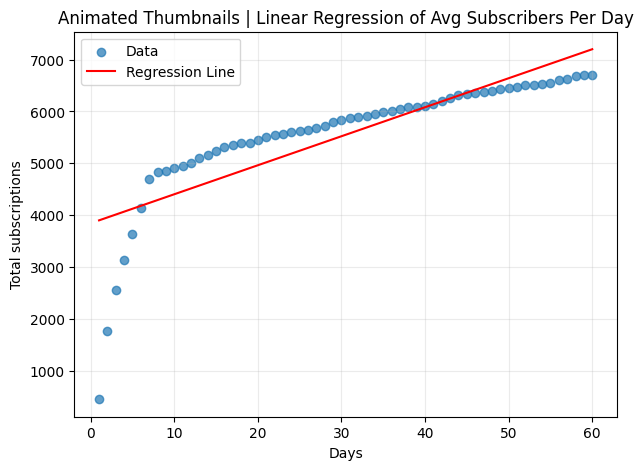

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(range(1,61), animatedAvg, alpha=0.7, label="Data")
plt.title("Animated Thumbnails | Linear Regression of Avg Subscribers Per Day")
plt.xlabel("Days")
plt.ylabel("Total subscriptions")

Xa = np.array(range(1,61)).reshape(-1,1) # need 2D array for linear regression

modelA = LinearRegression()
modelA.fit(Xa, animatedAvg)

predA = modelA.predict(Xa)
plt.plot(Xa, predA, color="red", label="Regression Line")

plt.grid(alpha=0.25)
plt.legend()
plt.show()

Well it does not fit everything but thats kinda cool, let's do the same thing with static thumbnails.

# 2. Static Thumbnails

In [ ]:
# STATIC THUMBNAILS
# stuff is not ordered again
# this data is retrieved from line 804 on all saved mod HTML files
static = {
    'Mod1' : [353,1191,1419,1883,2270,2504,2893,3065,3118,3120,3162,3271,3302,3374,3458,3513,3462,3441,3478,3468,3571,3693,3672,3621,3634,3668,3661,3708,3763,3784,3742,3775,3769,3773,3763,3787,3865,3832,3823,3834,3796,3888,3928,3940,3960,3938,3958,4019,4098,4181,4178,4183,4189,4188,4266,4307,4367,4348,4378,4361,4392,4410,4475,4536,4522,4482,4485,4524,4537,4566,4638,4614,4631,4639,4651,4656,4694,4791,4784,4749,4788,4783,4812,4887,4912,4908,4866,4876,4849,4844,4884,4906,4939,4893,4933,4927,4957,4974,5022,5043,5017,5036,5048,5051,5111,5142,5128,5093,5103,5108,5150,5222,5313,5390,5441,5551,5600,5596,5693,5818,5772,5691,5709,5715,5692,5741,5752,5784,5755,5743,5746,5772,5748,5838,5839,5781,5803,5836,5839,5848,5987,6040,6092,6053,6102,6159,6166,6238,6265,6173,6185,6179,6191,6202,6275,6337,6234,6240,6247,6286,6273,6308,6354,6347,6317,6302,6321,6333,6408,6392,6379,6376,6358,6368,6403,6432,6464,6452,6434,6420,6413,6457,6566,6591,6521,6525,6538,6506,6517,6550,6515,6560,6506,6534,6518,6530,6578,6472],
    'Mod2' : [510,1123,1292,1472,1783,1971,2168,2251,2316,2299,2328,2346,2356,2479,2587,2598,2512,2527,2577,2576,2638,2691,2733,2691,2715,2726,2757,2777,2806,2916,2893,2920,2948,2927,3030,3113,3112,3136,3111,3136,3183,3258,3334,3328,3349,3364,3360,3399,3433,3527,3527,3519,3520,3564,3569,3606,3681,3682,3656,3672,3720,3760,3757,3839,3852,3844,3840,3858,3854,3880,4006,3955,3951,3991,3989,4053,4120,4134,4127,4103,4119,4077,4090,4150,4135,4157,4121,4188,4183,4223,4237,4244,4290,4275,4289,4306,4322,4346,4385,4387,4344,4358,4374,4420,4473,4602,4718,4714,4824,4911,4919,5029,5145,5073,5022,5037,5024,5020,5061,5060,5120,5076,5059,5064,5078,5102,5177,5156,5119,5112,5147,5139,5168,5300,5374,5396,5361,5425,5496,5522,5573,5628,5539,5533,5544,5519,5547,5628,5684,5594,5588,5584,5614,5615,5657,5700,5697,5676,5670,5674,5720,5794,5759,5740,5753,5725,5747,5764,5784,5817,5808,5783,5785,5766,5812,5923,5943,5870,5884,5905,5844,5884,5910,5889,5893,5877,5877,5889,5882,5931,5840],
    'Mod3' : [280,930,1223,1396,1820,2211,2401,2309,2262,2250,2223,2278,2292,2323,2315,2338,2336,2371,2410,2472,2477,2444,2470,2497,2503,2546,2673,2772,2794,2786,2891,2957,2989,3080,3102,3049,3054,3064,3078,3092,3204,3269,3204,3199,3203,3245,3242,3296,3340,3333,3352,3344,3375,3385,3471,3442,3461,3456,3453,3473,3485,3517,3551,3541,3534,3527,3544,3567,3672,3671,3618,3626,3658,3632,3629,3709,3680,3715,3690,3721,3732,3728,3773,3683],
    'Mod4' : [93,763,1303,1710,2244,2834,3030,3063,3078,3184,3291,3325,3323,3338,3405,3440,3500,3574,3576,3615,3611,3660,3694,3719,3726,3738,3775,3805,3841,3875,3811,3855,3895,3915,3954,4026,4083,4061,4054,4061,4211,4453,4583,4681,4662,4695,4723,4748,4727,4943,5154,5039,5183,5257,5374,5599,5790,5882,5822,5833,5880,5864,5921,6145,6268,6179,6193,6236,6290,6359,6524,6509,6505,6583,6679,6702,6756,6755,6803,6778,6784,6850,6864,6903,6998,6987,6925,6869,6853,6844,6937,7006,6996,6862,6879,6892,6871,6917,6958,6980,6904,6917,6918,6887,6874,6883,6968,6925,6884,6892,6835,6920,6962,6934,6932,6910,6921,6959,7016,7088,7045,7021,7015,7003,7053,7078,7136,7101,7125,7113,7141,7143,7202,7240,7206,7182,7138,7162,7161,7211,7254,7198,7203,7211,7211,7211,7231,7327,7331,7289,7284,7288,7301,7377,7376,7349,7326,7304,7266,7284,7299,7297,7314,7277,7321,7288,7325,7334,7375,7384,7376,7352,7362,7374,7426,7441,7415,7363,7358,7369,7414,7473,7560,7613,7653,7725,7761,7781,7878,7954,7919,7836,7828,7827,7807,7841,7852,7855,7824,7793,7805,7801,7781,7874,7847,7778,7795,7811,7802,7816,7957,8004,8029,7974,8027,8072,8089,8154,8152,8075,8065,8065,8055,8066,8137,8200,8091,8088,8082,8121,8098,8156,8160,8137,8119,8100,8107,8115,8191,8164,8134,8132,8098,8103,8128,8181,8169,8154,8125,8103,8107,8138,8227,8243,8150,8138,8161,8119,8125,8158,8128,8169,8126,8125,8101,8130,8175,8084],
    'Mod5' : [141,1654,2399,2847,3399,3911,4237,4786,4779,4736,4740,4819,4838,4921,4969,4924,4862,4875,4865,4890,4929,5000,5039,4972,4954,4949,4950,4979,5028,5047,5038,5054,5059,5081,5131,5194,5189,5155,5169,5191,5188,5241,5246,5305,5297,5275,5300,5301,5365,5365,5359,5313,5327,5335,5329,5358,5387,5430,5395,5429,5428,5433,5472,5515,5512,5505,5502,5511,5509,5559,5603,5569,5550,5553,5484,5510,5545,5585,5585,5556,5570,5552,5566,5592,5670,5668,5652,5654,5626,5659,5657,5699,5698,5665,5707,5706,5699,5740,5780,5777,5741,5768,5769,5752,5793,5843,5838,5805,5820,5804,5812,5864,5872,5893,5862,5859,5871,5935,5922,5929,5940,5953,5969,6005,5996,6045,6033,6084,6077,6041,5983,6011,6003,6015,6013,5996,5968,6001,5999,6031,6021,6020,6034,6019,5985,5994,5988,6032,6029,6028,6009,6025,6026,6049,6080,6040,6020,6013,6022,6027,6009,6047,6030,6004,5983,5998,6010,6019,6023,6031,6003,6007,5992,5977,6040,6081,6079,6020,6031,6020,6030,6029,6060,6062,6008,6013,6010,6034,6027,6048,6045,6019,6024,6013,6016,6059,6081,6066,6040,6036,6030,6051,6044,6082,6084,6067,6049,6064,6050,6070,6105,6075,6071,6053,6060,6056,6070,6084,6054,6037,6036,6055,6037,6070,6076,6042,6054,6028,6012,6018,6015,6037,6028,5980,5980,5993,6005,5989,6010,6013,5974,5975,5969,5981,5988,6015,5984,6000,5976,6008,5976,6016,5999,6020,5987,6005,6006,5992,6004,6020,6034,5989,5965,5980,5985,5968,5980,5995,5976,5965,5962,5985,6001,5996,6026,6007,6003,6007,6015,5998,5992,6019,5982,6014,5970,5968,5982,5997,5967,5985,5952,5963,5956,5974,5951,5971,5977,5974,6018,6038,6066,6057,6057,6069,6042,6034,6051,6067,6045,6043,6049,6048,6052,6053,6053,6061,6041,6024,6068,6056,6047,6058,6086,6101,6071,6090,6083,6133,6117,6105,6118,6146,6124,6103,6089,6095,6132,6108,6078,6069,6072,6071,6089,6096,6111,6089,6103,6142,6174,6167,6324,6596,6778,6901,7019,7134,7221,7269,7249,7223,7213,7231,7201,7190,7236,7289,7282,7221,7223,7309,7353,7502,7545,7544,7618,7614,7687,7705,7838,7847,7783,7786,7805,7850,7821,7905,7954,7858,7871,7918,7914,7924,7996,8002,7939,7963,7983,8025,8055,8124,8131,8112,8116,8092,8139,8165,8163,8194,8164,8122,8106,8122,8161,8231,8243,8192,8164,8163,8180,8216,8251,8309,8224,8222,8224,8238,8255,8298,8302,8262,8249,8279,8258,8252,8281,8281,8254,8225,8227,8250,8283,8319,8304,8237,8250,8236,8233,8257,8292,8310,8276,8248,8240,8256,8302,8287,8301,8238,8225,8233,8246,8220,8216,8240,8201,8197,8209,8183,8216,8275,8251,8204,8203,8239,8252,8237,8254,8250,8225,8220,8181,8197,8200,8206,8217,8162,8165,8179,8187,8199,8221,8202,8197,8210,8195,8163,8177,8193,8183,8139,8104,8110,8062,8109,8153,8139,8132,8134,8113,8127,8146,8153,8156,8104,8105,8094,8084,8079,8079,8083,8075,8049,8031,8053,8049,8088,8134,8050,8018,8022,8030,8056,8056,8039,8039,8035,8023,8028,8019,8067,8027,7989,7978,7997,7980,8013,8065,8019,7980,7970,7990,8017,8030,8055,8024,7997,7992,7995,7946,7992,8024,8018,7995,8008,8000,7990,8010,8047,8029,7978,7972,7966,7950,7984,8014,8013,8001,7967,7967,8004,8013,8062,7988,7995,7962,7961,7981,8014,8018,8005,7979,7953,7928,7926,7924,7965,7983,7941,7922,7905,7912,7918,7935,7920,7890,7889,7892,7892,7893,7882,7875,7851,7830,7854,7860,7857,7879,7861,7834,7821,7823,7817,7811,7807,7814,7803,7779,7794,7786,7772,7787,7786,7771,7770,7771,7762,7776,7802,7794,7755,7749,7740,7745,7756,7750,7738,7738,7746,7718,7708,7713,7720,7691,7695,7680,7682,7686,7679,7647,7634,7620,7607,7614,7638,7597,7581,7596,7582,7591,7572,7577,7575,7585,7590,7567,7529,7541,7525,7502,7528,7512,7510,7509,7482,7467,7466,7424,7446,7441,7439,7450,7435,7423,7447,7434,7452,7419,7400,7381,7379,7367,7372,7364,7357,7359,7366,7360,7345,7327,7313,7296,7298,7314,7313,7306,7313,7307,7285,7297,7297,7287,7302,7302,7288,7295,7291,7284,7285,7289,7288,7275,7247,7269,7254,7244,7293,7305,7277,7246,7272,7266,7269,7287,7285,7265,7272,7251,7251,7256,7297,7288,7244,7248,7257,7246,7253,7265,7261,7226,7234,7225,7220,7215,7223,7229,7218,7210,7210,7217,7219,7224,7202,7198,7200,7195,7209,7216,7234,7244,7227,7207,7200,7196,7220,7226,7207,7183,7182,7183,7181,7188,7195,7214,7186,7188,7183,7203,7228,7235,7220,7206,7202,7208,7211,7222,7232,7264,7229,7222,7215,7206,7212,7246,7209,7191,7173,7154,7156,7195,7219,7194,7194,7189,7143,7139,7155,7133,7150,7108,7099,7109,7111,7086,7104,7115,7099,7081,7101,7078,7085,7103,7069,7053,7072,7069,7057,7086,7075,7066,7062,7060,7051,7044,7040,7024,7017,7011,7007,7008,6995,6980,7000,6993,6978,6977,6987,7003,6996,7029,7005,6989,6984,6960,6969,6972,6967,6980,6958,6949,6947,6943,6946,6976,6951,6938,6955,6952,6951,6953,6952,6969,6937,6937,6938,6925,6936,6919,6909,6912,6897,6903,6907,6887,6901,6903,6878,6860,6880,6860,6835,6843,6842,6831,6832,6812,6826,6817,6817,6806,6805,6808,6806,6789,6788,6791,6785,6767,6761,6764,6759,6749,6747,6737,6737,6738,6737,6719,6709,6713,6715,6713,6723,6711,6691,6687,6679,6674,6670,6683,6670,6656,6660,6668,6649,6649,6649,6656,6660,6658,6643,6625,6615,6601,6598,6591,6595,6598,6598,6595,6593,6585,6579,6585,6589,6574,6572,6573,6583,6565,6586,6576,6569,6544,6547,6544,6545,6542,6539,6527,6533,6532,6514,6513,6509,6519,6508,6495,6499,6485,6481,6479,6487,6471,6473,6478,6468,6465,6468,6479,6462,6458,6452,6452,6456,6450,6473,6456,6446,6448,6435,6434,6435,6432,6428,6412,6416,6414,6400,6403,6410,6408,6389,6388,6367,6366,6372,6366,6376,6366,6362,6355,6362,6363,6358,6355,6352,6345,6336,6329,6331,6334,6328,6309,6310,6309,6305,6291,6300,6314,6306,6301,6310,6299,6304,6296,6307,6296,6295,6291,6283,6285,6300,6280,6272,6273,6266,6280,6253,6264,6247,6247,6245,6243,6253,6252,6223,6231,6224,6220,6220,6214,6209,6222,6223,6214,6221,6205,6199,6202,6199,6204,6199,6202,6184,6202,6199,6201,6211,6193,6189,6171,6171,6166,6176,6154,6159,6158,6157,6156,6150,6130,6123,6129,6129,6134,6119,6126,6128,6126,6111,6118,6097,6114,6103,6099,6096,6092,6090,6102,6085,6086,6090,6086,6074,6076,6071,6068,6064,6076,6070,6059,6063,6068,6057,6055,6047,6048,6034,6034,6038,6045,6055,6055,6041,6033,6031,6035,6030,6019,6020,6030,6021,6009,6007,6004,5998,5999,5997,5987,6001,5991,5986,5981,5986,5979,5960,5956,5945,5954,5955,5961,5955,5945,5937,5935,5931,5939,5941,5939,5935,5938,5929,5921,5918,5926,5919,5917,5905,5910,5906,5889,5910,5896,5906,5892,5894,5897,5891,5895,5877],
    'Mod6' : [65,662,1093,1693,3434,3756,4020,4193,4242,4405,4464,4502,4572,4542,4561,4538,4499,4558,4635,4607,4572,4626,4656,4781,4853,4983,5019,4974,5003,5061,5078,5130,5176,5216,5178,5204,5223,5301,5391,5446,5539,5556,5544,5573,5581,5683,5751,5819,5778,5849,5868,5927,5980,6045,6052,6049,6039,6035,6052,6092,6124,6067,6090,6089,6084,6082,6100,6140,6136,6118,6081,6102,6093,6092,6147,6146,6166,6148,6125,6107,6146,6195,6204,6167,6191,6183,6208,6249,6246,6315,6317,6326,6343,6366,6443,6415,6536,6523,6588,6615,6748,6790,6817,6818,6808,6829,6807,6815,6856,6832,6843,6832,6822,6859,6825,6850,6852,6846,6877,6847,6872,6834,6843,6872,7011,7141,7143,7214,7248,7346,7420,7410,7485,7449,7482,7460,7473,7463,7517,7536,7508,7511,7523,7515,7525,7559,7538,7539,7585,7583,7630,7735,7812,7869,7989,8049,8185,8207,8212,8223,8220,8188,8230,8222,8252,8253,8264,8266,8226,8246,8250,8257,8286,8301,8261,8279,8290,8271,8312,8359,8361,8351,8362,8375,8328,8349,8401,8641,8712,8778,8824,8904,8912,9034,9060,9304,9342,9420,9499,9642,9844,9891,9767,9778,9778,9832,9973,10227,10349,10281,10180,10197,10216,10313,10500,10642,10477,10486,10521,10626,10721,10908,10972,10912,11061,11131,11177,11264,11433,11511,11438,11517,11530,11649,11720,11841,11867,11766,11800,11831,11873,11962,12161,12172,12095,12112,12071,12082,12133,12334,12338,12212,12237,12248,12281,12344,12545,12562,12464,12459,12412,12507,12634,12884,12779,12644,12765,12644,12702,12797,12917,12914,12846,12826,12855,12870,12922,13046,13011,12891,12890,12950,12934,12966,13134,13149,12992,13021,13036,13049,13108,13212,13198,13072,13085,13063,13083,13211,13304,13282,13237,13217,13279,13451,13440,13451,13455,13522,13527,13632,13593,13623,13584,13640,13703,13596,13540,13623,13632,13648,13708,13641,13606,13632,13683,13810,14029,14162,14202,14203,14242,14318,14296,14428,14447,14360,14307,14423,14415,14457,14629,14477,14444,14582,14446,14427,14481,14547,14551,14409,14421,14403,14453,14481,14576,14573,14461,14465,14434,14445,14564,14705,14749,14707,14651,14673,14743,14757,14869,14854,14671,14671,14642,14676,14677,14818,14791,14680,14715,14647,14649,14771,14971,14905,14739,14715,14772,14799,14821,15006,14984,14865,14833,14924,14926,15042,15212,15148,15019,14950,14978,15013,15097,15211,15202,15073,15031,15094,15047,15140,15209,15178,15200,15125,15185,15216,15326,15493,15582,15379,15341,15425,15470,15552,15779,15914,15742,15761,15821,15879,15989,16192,16218,16238,16105,16168,16408,16557,16651,16712,16549,16538,16552,16588,16764,16943,16917,16730,16717,16797,16814,16839,17041,17000,16924,16917,16977,16961,17008,17118,17278,17066,17017,17023,17075,17095,17154,17129,17028,17071,17031,17009,17031,17079,17044,17022,16907,16958,16978,17022,17070,17114,16990,16980,17010,17037,17067,17026,17023,17021,16987,17039,17197,17297,17306,17320,17256,17251,17232,17236,17269,17248,17323,17278,17329,17312,17352,17259,17359,17403,17344,17340,17289,17318,17336,17302,17356,17343,17346,17282,17222,17247,17229,17210,17176,17173,17159,17192,17129,17153,17145,17155,17166,17189,17292,17241,17460,17748,17855,17964,18128,18256,18257,18343,18398,18348,18246,18257,18179,18177,18255,18316,18235,18151,18138,18277,18311,18508,18485,18506,18482,18448,18524,18516,18742,18737,18565,18537,18557,18641,18616,18751,18824,18681,18698,18752,18787,18785,18973,19016,18898,18907,18966,19074,19191,19377,19424,19370,19475,19481,19559,19685,19821,19935,19813,19736,19731,19776,19853,20047,20053,19889,19811,19871,19865,19969,20135,20199,20082,20066,20100,20089,20118,20202,20213,20110,20062,20135,20118,20107,20205,20132,20056,20046,20064,20069,20141,20294,20241,20136,20107,20128,20136,20207,20302,20346,20213,20089,20165,20171,20347,20381,20238,20176,20149,20133,20211,20269,20292,20199,20202,20157,20182,20218,20390,20274,20151,20094,20232,20152,20218,20369,20331,20155,20144,20139,20173,20195,20340,20302,20172,20158,20152,20125,20190,20346,20289,20186,20185,20187,20234,20330,20401,20371,20199,20224,20175,20199,20292,20368,20372,20282,20238,20236,20270,20279,20339,20289,20250,20201,20224,20201,20246,20271,20303,20123,20136,20108,20068,20115,20247,20235,20133,20123,20070,20048,20111,20176,20181,20058,20001,20037,20044,20089,20197,20209,20080,20091,20143,20081,20146,20269,20244,20075,20044,20062,20118,20054,20155,20221,20131,20049,20086,20075,20075,20165,20213,20161,20080,20131,20102,20143,20212,20242,20069,20063,20031,20051,20078,20146,20124,20094,20112,20073,20093,20153,20198,20142,20106,20070,20083,20081,20082,20073,20105,20037,20026,20028,20016,19918,19945,19980,19956,19937,19936,19933,19945,19993,20037,19985,19957,19977,19987,19928,19883,19905,19900,19948,19830,19780,19819,19757,19794,19742,19765,19800,19768,19800,19792,19836,19886,19781,19787,19780,19745,19750,19746,19740,19756,19752,19786,19804,19772,19729,19717,19661,19671,19619,19663,19663,19666,19601,19555,19577,19555,19559,19580,19603,19524,19511,19518,19509,19517,19521,19547,19506,19496,19502,19500,19438,19520,19551,19493,19419,19469,19448,19440,19528,19507,19386,19405,19369,19395,19409,19521,19541,19452,19466,19426,19442,19458,19529,19508,19415,19429,19458,19519,19489,19623,19590,19490,19451,19457,19455,19460,19501,19493,19484,19467,19426,19470,19482,19549,19610,19459,19402,19395,19410,19453,19525,19449,19359,19389,19342,19325,19377,19456,19465,19378,19376,19316,19394,19446,19428,19446,19369,19370,19362,19357,19360,19523,19612,19494,19494,19506,19460,19529,19719,19708,19672,19613,19621,19626,19689,19722,19766,19652,19579,19554,19595,19595,19661,19668,19457,19460,19493,19474,19508,19607,19605,19534,19460,19486,19463,19494,19605,19552,19465,19496,19537,19496,19568,19683,19672,19587,19603,19536,19613,19581,19560,19595,19608,19603,19625,19569,19579,19584,19632,19587,19566,19586,19556,19608,19669,19648,19518,19522,19536,19540,19585,19707,19545,19418,19457,19451,19437,19372,19383,19373,19354,19369,19397,19344,19275,19289,19302,19291,19339,19362,19372,19312,19313,19287,19294,19327,19318,19308,19304,19257,19261,19284,19261,19293,19342,19291,19260,19233,19233,19216,19262,19249,19237,19198,19158,19150,19125,19123,19114,19095,19102,19097,19089,19142,19119,19101,19055,19032,19044,19050,19015,19041,19041,19004,19003,18967,18951,18943,18970,18976,18954,18954,18967,18928,18927,18953,18909,18906,18901,18894,18870,18857,18930,18917,18887,18910,18866,18913,18907,18895,18859,18843,18783,18833,18836,18800,18801,18770,18764,18727,18716,18700,18696,18723,18688,18658,18653,18659,18619,18646,18616,18645,18602,18575,18585,18547,18592,18585,18610,18627,18560,18529,18544,18544,18519,18537,18509,18456,18441,18421,18446,18524,18505,18450,18450,18462,18441,18458,18496,18529,18433,18440,18428,18436,18428,18505,18492,18411,18382,18385,18387,18398,18406,18381,18335,18357,18345,18351,18336,18386,18417,18323,18329,18321,18278,18313,18349,18351,18319,18295,18262,18275,18311,18330,18320,18264,18245,18223,18212,18245,18255,18297,18237,18223,18244,18239,18203,18265,18310,18232,18188,18234,18187,18224,18256,18236,18160,18157,18169,18141,18180,18206,18220,18149,18160,18135,18139,18131,18165,18122,18088,18056,18070,18049,18071,18087,18077,18020,17992,18002,17987,17994,18000,18031,17949,17942,17942,17917,17900,17969,17965,17896,17854,17868,17856,17909,17950,17938,17937,17890,17854,17834,17894,17914,17878,17834,17862,17824,17836,17834,17858,17863,17804,17760,17812,17779,17808,17851,17793,17737,17709,17740,17757,17726,17795,17805,17748,17699,17687,17689,17688,17740,17731,17650,17633,17615,17568,17587,17667,17680,17607,17581,17597,17581,17597,17631,17595,17515,17491,17544,17580,17680,17731,17754,17717,17697,17748,17699,17733,17819,17882,17808,17786,17732,17745,17756,17854,17859,17756,17776,17745,17767,17779,17857,17818,17795,17721,17733,17706,17747,17751,17719,17690,17671,17645,17656,17696,17711,17737,17677,17684,17647,17681,17697,17744,17755,17660,17667,17634,17639,17646,17661,17649,17569,17562,17539,17524,17533,17563,17474],
    'Mod7' : [598,1187,1653,2031,2535,2953,3382,3430,3502,3571,3656,3675,3751,3778,3779,3798,3835,3824,3807,3859,3880,3882,3898,3893,3934,3911,3926,3963,4166,4324,4351,4435,4508,4619,4700,4683,4760,4731,4786,4782,4793,4796,4856,4879,4877,4874,4916,4933,4952,4976,4966,4993,5042,5053,5103,5221,5301,5392,5553,5583,5755,5767,5785,5776,5809,5794,5841,5831,5874,5888,5899,5919,5876,5913,5929,5931,6004,6001,5980,6001,6019,6023,6057,6103,6120,6116,6119,6150,6130,6134,6212,6458,6533,6621,6704,6796,6808,6930,6940,6923,6904,6929,6934,6980,7016,6959,6929,6923,6925,6938,6990,7021,7046,6987,6968,6947,6957,6955,7011,7008,6982,7007,7008,7026,7054,7109,7068,7025,7031,7039,7033,7063,7095,7126,7093,7108,7089,7112,7163,7177,7144,7106,7109,7086,7094,7109,7137,7137,7086,7132,7130,7118,7150,7200,7215,7183,7168,7174,7182,7209,7258,7215,7180,7184,7150,7161,7176,7217,7240,7179,7202,7181,7170,7193,7264,7276,7230,7207,7188,7196,7205,7229,7219,7204,7200,7191,7173,7205,7267,7261,7222,7225,7218,7224,7259,7287,7294,7228,7224,7228,7227,7284,7285,7298,7283,7281,7307,7375,7367,7385,7396,7402,7428,7448,7426,7476,7440,7486,7439,7451,7373,7398,7400,7412,7382,7363,7354,7362,7368,7410,7397,7401,7388,7393,7343,7356,7344,7373,7394,7363,7337,7355,7335,7364,7404,7358,7305,7323,7306,7300,7285,7332,7329,7284,7287,7297,7305,7311,7317,7325,7278,7272,7262,7258,7318,7349,7365,7306,7302,7302,7281,7300,7330,7320,7261,7246,7244,7283,7265,7290,7294,7256,7241,7223,7239,7278,7320,7308,7259,7256,7249,7268,7254,7311,7321,7283,7244,7265,7248,7270,7312,7289,7275,7254,7275,7261,7281,7290,7246,7232,7244,7239,7217,7237,7265,7249,7250,7215,7215,7219,7219,7250,7230,7177,7165,7162,7192,7179,7203,7197,7160,7150,7152,7147,7163,7204,7162,7179,7153,7173,7143,7178,7189,7208,7167,7179,7178,7175,7180,7204,7205,7148,7121,7139,7142,7116,7131,7136,7120,7098,7123,7123,7142,7148,7158,7122,7130,7143,7152,7138,7146,7167,7126,7138,7100,7099,7111,7156,7113,7147,7114,7137,7153,7170,7133,7144,7137,7128,7160,7187,7218,7194,7212,7231,7207,7207,7223,7214,7196,7208,7195,7202,7203,7185,7212,7203,7197,7211,7245,7201,7202,7196,7243,7250,7229,7237,7235,7278,7241,7245,7259,7255,7252,7223,7221,7220,7242,7223,7210,7204,7180,7192,7188,7191,7220,7203,7212,7244,7264,7249,7413,7696,7859,7978,8103,8205,8279,8341,8327,8285,8276,8306,8258,8241,8301,8350,8369,8298,8300,8389,8402,8584,8596,8609,8663,8649,8722,8746,8879,8909,8846,8834,8874,8910,8868,8963,9020,8920,8936,8988,8967,8981,9055,9069,9019,9039,9066,9104,9130,9184,9207,9178,9170,9152,9195,9211,9235,9267,9246,9207,9196,9206,9247,9304,9305,9254,9221,9251,9254,9286,9329,9388,9293,9302,9300,9307,9320,9364,9368,9322,9296,9329,9310,9309,9350,9338,9307,9286,9283,9310,9342,9377,9353,9279,9296,9292,9285,9317,9347,9348,9319,9295,9289,9296,9335,9350,9339,9281,9259,9263,9283,9269,9266,9273,9232,9237,9244,9224,9257,9320,9290,9230,9227,9280,9275,9273,9294,9278,9247,9231,9188,9192,9202,9220,9241,9166,9169,9184,9177,9196,9215,9189,9187,9190,9178,9156,9158,9178,9176,9112,9076,9088,9033,9077,9124,9091,9089,9088,9074,9092,9114,9128,9120,9062,9060,9051,9054,9043,9045,9047,9022,9002,8988,9005,9006,9041,9058,8980,8939,8938,8959,8973,8980,8962,8962,8944,8950,8945,8943,8983,8949,8918,8902,8923,8911,8931,8989,8929,8909,8893,8901,8914,8936,8962,8930,8904,8891,8886,8855,8897,8943,8946,8913,8922,8925,8909,8917,8959,8933,8883,8875,8861,8845,8877,8904,8905,8901,8864,8865,8901,8910,8958,8887,8888,8863,8853,8874,8902,8881,8880,8848,8825,8802,8799,8791,8822,8832,8795,8795,8773,8776,8781,8794,8768,8745,8749,8741,8743,8734,8749,8730,8703,8679,8699,8699,8701,8733,8720,8682,8660,8676,8657,8655,8666,8664,8636,8629,8622,8613,8602,8620,8612,8611,8583,8583,8570,8579,8606,8576,8548,8545,8554,8545,8546,8549,8533,8524,8523,8499,8486,8511,8516,8507,8493,8468,8471,8462,8456,8433,8424,8410,8405,8404,8438,8384,8379,8384,8360,8362,8351,8345,8342,8343,8348,8331,8283,8297,8289,8258,8277,8261,8248,8241,8235,8199,8194,8158,8177,8172,8178,8190,8182,8167,8208,8188,8218,8173,8154,8134,8137,8115,8118,8112,8108,8109,8116,8101,8100,8069,8070,8038,8048,8037,8053,8049,8036,8011,7997,7996,8000,8006,7986,7980,7992,7973,7977,8004,7981,7962,7979,7974,7972,7983,7980,7980,7965,7961,7959,7950,7968,7939,7925,7926,7906,7917,7917,7896,7905,7915,7897,7872,7882,7870,7846,7852,7860,7843,7835,7830,7835,7833,7824,7806,7816,7803,7804,7782,7784,7787,7789,7758,7754,7756,7747,7728,7736,7729,7722,7717,7726,7702,7695,7690,7686,7682,7693,7690,7669,7677,7676,7658,7653,7664,7651,7644,7633,7653,7634,7640,7639,7640,7650,7647,7624,7605,7605,7592,7590,7587,7587,7600,7599,7598,7587,7590,7572,7586,7579,7579,7570,7568,7580,7569,7588,7581,7579,7555,7558,7552,7545,7543,7544,7527,7539,7524,7512,7502,7504,7504,7501,7485,7478,7468,7468,7464,7475,7453,7453,7464,7464,7463,7460,7471,7453,7439,7440,7442,7445,7436,7452,7449,7428,7434,7424,7430,7421,7419,7422,7409,7408,7410,7392,7389,7402,7390,7381,7369,7364,7366,7371,7370,7377,7363,7360,7357,7360,7364,7359,7355,7351,7355,7338,7336,7338,7337,7335,7322,7318,7326,7307,7297,7306,7322,7303,7297,7308,7299,7301,7298,7293,7284,7276,7273,7264,7263,7275,7257,7246,7248,7241,7244,7227,7234,7212,7207,7211,7204,7208,7210,7191,7198,7187,7186,7183,7175,7168,7176,7181,7177,7174,7155,7150,7151,7152,7157,7156,7157,7140,7145,7150,7151,7156,7143,7135,7116,7122,7118,7126,7113,7117,7117,7114,7110,7101,7091,7082,7086,7084,7106,7086,7096,7085,7090,7074,7083,7065,7067,7071,7060,7053,7050,7043,7051,7038,7034,7036,7041,7016,7017,7019,7016,7001,7028,7008,7006,7001,7005,6999,6997,6991,6986,6973,6971,6978,6983,6986,6999,6989,6980,6971,6968,6972,6969,6970,6979,6957,6953,6944,6953,6952,6946,6950,6935,6935,6930,6929,6925,6930,6919,6904,6892,6894,6894,6892,6899,6894,6886,6869,6868,6857,6869,6869,6872,6863,6866,6858,6852,6843,6862,6853,6844,6840,6846,6839,6826,6846,6834,6845,6832,6834,6826,6817,6823,6806],
    'Mod8' : [66,556,1046,1747,2606,3065,3197,3458,3529,3657,3735,3868,3932,3893,3884,3863,3888,3909,3949,3933,3933,3957,3963,3986,3995,4012,4020,4013,3991,4017,4006,4020,4085,4099,4113,4101,4093,4093,4127,4177,4220,4178,4164,4182,4195,4249,4270,4379,4383,4400,4454,4491,4593,4581,4700,4687,4746,4776,4903,4960,5000,5038,5042,5067,5066,5082,5134,5138,5141,5118,5143,5162,5138,5191,5186,5203,5225,5228,5251,5209,5224,5286,5463,5579,5610,5683,5753,5876,5911,5918,6000,5957,5995,6004,6017,5992,6048,6077,6061,6057,6076,6083,6108,6127,6094,6340,6499,6674,6856,7082,7273,7424,7637,7722,7859,7916,7966,7959,7953,7961,7998,8028,8092,8117,8157,8160,8119,8151,8135,8122,8171,8163,8149,8160,8173,8148,8201,8247,8266,8246,8255,8293,8253,8298,8418,8642,8716,8768,8838,8895,8952,9057,9031,9032,9008,9021,9005,9070,9098,9057,9018,8982,8988,8982,9027,9078,9086,9022,9009,8962,8994,8973,9020,9008,8981,8981,8962,8993,9036,9064,9051,8998,9005,9010,9009,9048,9087,9129,9094,9081,9055,9064,9122,9118,9098,9056,9063,9017,9015,9016,9080,9098,9032,9066,9069,9040,9085,9128,9128,9088,9081,9058,9061,9089,9142,9094,9054,9037,8996,9016,9046,9089,9096,9026,9069,9018,9019,9034,9085,9095,9050,9042,9014,9017,9029,9039,9036,9006,9028,9005,9009,9052,9104,9098,9043,9055,9055,9041,9080,9133,9119,9063,9047,9075,9056,9108,9124,9141,9117,9102,9100,9167,9141,9123,9117,9143,9162,9196,9181,9207,9191,9209,9185,9178,9116,9124,9145,9122,9134,9076,9054,9050,9066,9112,9087,9090,9076,9058,9022,9025,9034,9054,9053,9046,9003,9016,9006,9027,9064,9027,8990,8997,8995,8980,8962,9016,8998,8955,8941,8952,8953,8952,8964,8945,8919,8910,8896,8890,8947,8974,8982,8909,8918,8912,8902,8931,8945,8926,8865,8852,8847,8883,8867,8896,8901,8836,8840,8821,8831,8861,8899,8896,8843,8842,8846,8856,8856,8902,8909,8866,8843,8862,8836,8861,8903,8880,8840,8831,8839,8853,8862,8887,8838,8810,8826,8817,8818,8859,8861,8814,8821,8788,8774,8779,8777,8792,8788,8739,8713,8721,8740,8735,8737,8726,8683,8693,8668,8677,8706,8725,8708,8686,8672,8683,8662,8706,8717,8739,8680,8700,8696,8699,8710,8747,8744,8677,8663,8696,8687,8653,8670,8686,8664,8658,8668,8662,8679,8681,8713,8656,8673,8669,8689,8670,8687,8714,8666,8677,8646,8648,8665,8657,8608,8638,8593,8612,8610,8626,8598,8617,8619,8630,8644,8675,8678,8682,8677,8685,8662,8681,8707,8680,8678,8678,8692,8685,8701,8693,8709,8719,8708,8708,8722,8728,8718,8700,8741,8751,8733,8755,8756,8777,8778,8779,8789,8781,8781,8749,8731,8738,8759,8738,8732,8714,8714,8715,8714,8713,8744,8715,8731,8753,8767,8757,8914,9210,9340,9495,9610,9700,9787,9832,9823,9789,9791,9799,9762,9747,9799,9854,9868,9775,9788,9864,9884,10059,10085,10095,10161,10164,10227,10255,10374,10395,10324,10318,10355,10388,10350,10446,10482,10390,10405,10455,10440,10454,10513,10545,10473,10503,10514,10558,10566,10640,10631,10630,10628,10600,10633,10668,10660,10681,10657,10630,10631,10628,10658,10724,10727,10689,10651,10668,10673,10715,10749,10801,10722,10715,10718,10722,10731,10765,10772,10736,10709,10750,10738,10735,10782,10758,10739,10726,10709,10729,10751,10803,10760,10700,10719,10716,10706,10724,10750,10773,10744,10709,10713,10720,10744,10756,10783,10721,10715,10710,10748,10720,10721,10724,10674,10673,10677,10659,10697,10756,10722,10683,10668,10699,10699,10680,10699,10680,10646,10644,10603,10608,10610,10633,10629,10571,10582,10576,10565,10583,10595,10564,10565,10558,10564,10552,10530,10571,10558,10487,10473,10473,10411,10480,10534,10521,10541,10561,10543,10573,10574,10616,10622,10553,10554,10534,10535,10522,10533,10556,10515,10490,10487,10503,10501,10536,10580,10507,10451,10463,10467,10488,10497,10491,10487,10459,10438,10438,10419,10458,10413,10377,10355,10368,10356,10376,10407,10370,10315,10310,10319,10345,10364,10394,10352,10342,10322,10309,10282,10317,10375,10351,10323,10312,10327,10303,10324,10383,10341,10286,10272,10270,10251,10284,10322,10311,10311,10255,10283,10312,10317,10355,10289,10283,10249,10243,10258,10280,10270,10265,10238,10212,10203,10186,10195,10236,10260,10208,10193,10181,10191,10209,10213,10191,10161,10170,10163,10169,10156,10156,10131,10110,10097,10113,10117,10117,10154,10128,10092,10076,10081,10072,10086,10067,10078,10040,10051,10043,10044,10047,10068,10062,10047,10021,10026,10005,10034,10061,10025,9990,9989,9988,9975,9972,9974,9953,9950,9942,9920,9916,9928,9923,9905,9912,9883,9886,9885,9895,9857,9846,9818,9817,9815,9833,9808,9771,9797,9770,9770,9775,9776,9767,9783,9805,9765,9707,9726,9709,9690,9725,9692,9695,9679,9677,9668,9662,9635,9647,9642,9646,9649,9627,9608,9636,9621,9641,9614,9591,9566,9563,9564,9566,9559,9553,9555,9566,9553,9540,9498,9496,9474,9486,9479,9484,9491,9498,9483,9477,9484,9489,9489,9480,9485,9474,9468,9460,9458,9464,9453,9473,9441,9422,9435,9417,9421,9468,9469,9446,9418,9439,9443,9441,9457,9451,9426,9424,9402,9411,9423,9467,9453,9425,9411,9405,9411,9399,9420,9422,9379,9378,9368,9363,9366,9371,9374,9355,9335,9335,9346,9335,9347,9333,9315,9326,9321,9341,9349,9358,9374,9334,9328,9324,9322,9339,9330,9296,9284,9282,9272,9281,9293,9295,9310,9274,9279,9281,9290,9309,9303,9292,9264,9251,9263,9273,9284,9287,9326,9299,9291,9290,9285,9292,9329,9278,9263,9245,9222,9234,9274,9304,9289,9274,9262,9218,9219,9231,9227,9216,9184,9187,9179,9181,9167,9184,9200,9175,9159,9174,9159,9150,9168,9142,9140,9140,9132,9118,9156,9145,9155,9129,9127,9098,9085,9105,9085,9081,9082,9063,9074,9072,9049,9067,9065,9077,9080,9104,9115,9125,9300,9305,9279,9296,9315,9326,9327,9388,9382,9356,9378,9390,9373,9377,9393,9385,9385,9379,9391,9386,9400,9434,9461,9435,9441,9449,9436,9429,9461,9485,9475,9483,9462,9499,9529,9566,9570,9558,9588,9613,9588,9575,9604,9648,9599,9589,9576,9577,9577,9592,9609,9618,9619,9621,9578,9591,9634,9606,9572,9578,9550,9578,9589,9604,9604,9608,9586,9578,9577,9575,9588,9582,9575,9557,9571,9585,9603,9600,9621,9601,9622,9610,9615,9614,9634,9635,9596,9605,9598,9612,9590,9620,9626,9602,9595,9608,9599,9588,9601,9588,9589,9599,9594,9591,9615,9615,9636,9606,9584,9600,9592,9594,9595,9604,9575,9568,9601,9580,9588,9627,9596,9578,9596,9596,9592,9613,9601,9592,9571,9578,9577,9571,9573,9564,9564,9566,9547,9562,9580,9563,9593,9584,9584,9550,9573,9564,9526,9569,9577,9571,9549,9550,9559,9567,9568,9544,9561,9533,9537,9546,9546,9561,9537,9526,9535,9542,9537,9523,9520,9517,9505,9515,9518,9494,9481,9488,9524,9488,9518,9503,9488,9491,9504,9479,9471,9496,9493,9478,9477,9487,9463,9460,9464,9472,9484,9473,9466,9441,9437,9427,9429,9432,9429,9443,9430,9422,9419,9425,9405,9405,9403,9404,9383,9414,9392,9387,9405,9397,9403,9372,9378,9364,9360,9360,9369,9360,9351,9355,9327,9322,9321,9313,9319,9325,9321,9286,9292,9284,9305,9299,9277,9275,9290,9275,9282,9300,9285,9272,9265,9264,9254,9244,9271,9257,9240,9249,9221,9227,9218,9238,9223,9220,9203,9215,9186,9191,9199,9193,9160,9164,9151,9145,9177,9160,9175,9145,9158,9154,9160,9155,9158,9148,9130,9129,9118,9114,9128,9126,9124,9102,9095,9100,9098,9144,9285,9364,9378,9373,9406,9425,9484,9567,9645,9629,9652,9695,9646,9679,9716,9744,9744,9747,9733,9757,9770,9794,9811,9805,9804,9813,9833,9824,9848,9868,9856,9849,9861,9861,9856,9902,9916,10028,9759,9732,9733,9723,9736,9749,9738,9738,9712,9718,9727,9738,9749,9713,9715,9685,9685,9678,9718,9725,9711,9696,9697,9673,9663,9676,9643,9652,9633,9637,9632,9637,9634,9625,9579,9607,9584,9599,9631,9653,9679,9689,9689,9692,9689,9711,9737,9706,9687,9663,9661,9669,9640,9669,9656,9642,9639,9652,9635,9636,9618,9634,9592,9589,9597,9601,9609,9610,9608,9597,9610,9595,9611,9605,9594,9604,9581,9571,9560,9572,9566,9596,9572,9562,9559,9549,9540,9550,9548,9538,9525,9522,9525,9530,9513,9509,9517,9498,9481,9467,9467,9475,9499,9478,9480,9484,9472,9468,9462,9490,9487,9446,9448,9451,9429,9428,9449,9430,9409,9396,9392,9384,9378,9397,9360],
    'Mod9' : [71,1155,2076,2798,3272,3713,4066,4436,4659,4780,4716,4781,4807,4830,4891,4987,4999,5007,5030,5110,5105,5200,5268,5263,5295,5357,5447,5510,5634,5798,5865,5820,5851,5854,5830,5875,5888,5864,5896,5867,5853,5845,5884,5870,5916,5889,5873,5909,5957,5995,6101,6100,6081,6133,6166,6201,6301,6751,6750,6718,6750,6720,6798,6780,6825,6829,6818,6826,6795,6763,6787,6860,6809,6782,6806,6822,6943,7003,7119,6965,6920,6919,6926,6933,6908,6907,6901,6892,6907,6923,6900,6885,6897,6890,6885,6897,6885,6889,6868,6850,6851,6850,6860,6843,6815,6829,6811,6820,6825,6800,6819,6821,6807,6779,6790,6780,6756,6767,6768,6759,6741,6739,6735,6732,6730,6708,6715,6704,6716,6700,6695,6704,6688,6661,6657,6659,6658,6628,6643,6630,6629,6625,6635,6608,6601,6605,6598,6597,6606,6594,6577,6587,6577,6565,6563,6573,6562,6552,6540,6558,6545,6542,6541,6548,6552,6549,6533,6518,6507,6490,6481,6479,6481,6486,6486,6483,6466,6474,6450,6464,6464,6442,6434,6444,6456,6447,6461,6448,6446,6425,6425,6415,6414,6415,6409,6395,6399,6384,6373,6372,6365,6369,6366,6351,6348,6341,6338,6338,6347,6325,6322,6331,6328,6328,6324,6335,6314,6303,6300,6297,6305,6298,6304,6303,6277,6277,6267,6268,6257,6261,6260,6252,6252,6247,6238,6240,6248,6240,6225,6221,6212,6205,6215,6208,6211,6208,6201,6187,6198,6197,6193,6185,6185,6186,6174,6172,6172,6162,6158,6145,6136,6137,6131,6117,6116,6133,6123,6127,6126,6113,6119,6109,6107,6107,6098,6097,6073,6082,6088,6071,6066,6070,6059,6061,6047,6048,6028,6026,6019,6017,6013,6023,5999,6003,5986,5984,5984,5972,5963,5972,5975,5968,5966,5946,5940,5938,5935,5942,5945,5934,5921,5930,5934,5938,5937,5911,5910,5890,5893,5889,5901,5886,5882,5887,5877,5865,5867,5861,5841,5848,5842,5865,5842,5847,5835,5847,5832,5843,5822,5832,5834,5827,5808,5807,5800,5814,5802,5800,5805,5800,5785,5777,5778,5776,5771,5785,5763,5762,5753,5758,5753,5751,5742,5742,5722,5723,5725,5740,5738,5745,5735,5732,5717,5709,5719,5712,5703,5715,5692,5688,5682,5687,5682,5687,5679,5669,5671,5659,5659,5648,5653,5651,5636,5623,5622,5629,5627,5629,5621,5612,5599,5600,5596,5604,5616,5606,5601,5594,5581,5582,5571,5581,5574,5566,5565,5571,5563,5548,5565,5554,5558,5546,5544,5541,5534,5534,5519],
    'Mod10' : [76,644,1043,1510,2058,2594,2997,3197,3248,3281,3326,3404,3516,3483,3484,3512,3541,3564,3606,3633,3650,3629,3595,3622,3614,3616,3661,3682,3726,3725,3711,3728,3752,3834,3852,3819,3844,3869,3910,3963,3996,4079,4071,4117,4141,4173,4262,4255,4388,4406,4464,4529,4681,4748,4802,4839,4847,4910,4925,4953,4999,5037,5059,5048,5073,5099,5084,5139,5156,5196,5200,5201,5229,5189,5213,5280,5439,5583,5612,5706,5777,5883,5974,5974,6032,5994,6062,6036,6060,6050,6129,6157,6131,6136,6158,6166,6181,6205,6195,6216,6262,6274,6324,6427,6494,6583,6706,6759,6896,6934,6943,6956,6943,6957,6969,6971,6992,7006,7021,7030,7012,7034,7019,7054,7085,7107,7072,7089,7096,7095,7124,7173,7202,7195,7193,7220,7189,7200,7262,7512,7564,7658,7699,7786,7820,7926,7911,7877,7867,7886,7897,7932,7978,7926,7886,7875,7873,7885,7924,7956,7968,7917,7912,7880,7882,7872,7906,7893,7858,7878,7868,7904,7922,7973,7956,7908,7931,7924,7928,7969,7984,8009,7968,7981,7966,7991,8028,8040,8008,7981,7990,7966,7977,7988,8019,8048,7979,8008,8019,7990,8022,8060,8075,8046,8037,8026,8047,8073,8106,8049,8018,8004,7974,7991,8017,8064,8069,8008,8035,8009,8006,8032,8096,8095,8058,8043,8002,8019,8028,8036,8034,7999,7998,8001,7988,8016,8081,8058,8019,8045,8048,8023,8059,8112,8092,8060,8054,8047,8054,8089,8093,8087,8059,8040,8034,8115,8087,8086,8100,8103,8104,8120,8123,8159,8140,8188,8166,8135,8065,8103,8103,8103,8109,8066,8049,8060,8080,8100,8076,8100,8090,8093,8037,8040,8037,8073,8073,8043,8019,8039,8021,8054,8080,8042,7990,8019,8011,8001,7989,8014,7997,7960,7949,7969,7969,7967,7979,7981,7945,7925,7924,7907,7965,8012,8015,7949,7944,7941,7937,7933,7973,7976,7911,7884,7881,7923,7906,7928,7917,7863,7873,7856,7858,7900,7927,7919,7878,7872,7875,7884,7885,7908,7902,7876,7858,7872,7856,7870,7904,7884,7869,7848,7861,7868,7869,7880,7847,7837,7849,7841,7839,7866,7873,7836,7843,7806,7804,7797,7787,7811,7818,7778,7766,7767,7787,7775,7796,7789,7736,7746,7738,7739,7747,7777,7753,7746,7726,7738,7708,7741,7752,7761,7729,7737,7738,7737,7743,7763,7761,7706,7681,7695,7694,7679,7685,7692,7674,7657,7674,7676,7682,7679,7716,7680,7671,7676,7701,7688,7683,7720,7675,7690,7641,7644,7674,7681,7644,7655,7611,7631,7631,7641,7617,7638,7635,7634,7666,7688,7715,7689,7691,7714,7690,7701,7724,7713,7704,7704,7706,7688,7702,7690,7721,7712,7725,7723,7749,7721,7728,7736,7762,7772,7754,7764,7746,7794,7773,7779,7773,7774,7767,7742,7737,7732,7768,7744,7727,7712,7707,7709,7706,7699,7746,7719,7728,7753,7777,7757,7913,8192,8368,8488,8616,8708,8791,8844,8829,8798,8781,8821,8764,8756,8789,8835,8860,8787,8791,8869,8899,9078,9097,9095,9152,9154,9220,9239,9371,9402,9319,9320,9343,9382,9353,9438,9493,9394,9408,9461,9437,9447,9524,9558,9493,9518,9529,9577,9609,9662,9676,9651,9639,9620,9672,9682,9694,9713,9679,9631,9629,9647,9679,9726,9730,9690,9658,9672,9683,9721,9766,9830,9747,9746,9748,9757,9769,9799,9807,9781,9766,9794,9775,9775,9815,9792,9777,9755,9741,9762,9793,9838,9816,9749,9760,9750,9758,9780,9807,9850,9802,9772,9780,9781,9811,9811,9823,9763,9748,9759,9767,9750,9744,9747,9704,9706,9714,9680,9708,9775,9745,9689,9678,9710,9713,9704,9750,9718,9692,9689,9638,9651,9666,9675,9685,9614,9622,9641,9619,9645,9661,9635,9631,9639,9630,9584,9585,9611,9600,9536,9491,9501,9446,9490,9537,9510,9520,9499,9480,9527,9559,9598,9616,9553,9554,9544,9555,9546,9560,9560,9553,9518,9525,9556,9541,9576,9605,9538,9509,9497,9511,9512,9533,9504,9508,9476,9467,9462,9456,9501,9463,9420,9407,9428,9411,9438,9480,9419,9383,9374,9381,9401,9417,9454,9413,9393,9377,9381,9338,9368,9419,9415,9382,9377,9384,9374,9381,9419,9394,9348,9342,9338,9306,9340,9408,9382,9391,9358,9359,9400,9400,9467,9374,9377,9344,9336,9347,9385,9372,9363,9325,9305,9285,9275,9273,9309,9327,9296,9279,9253,9261,9268,9277,9261,9227,9223,9227,9232,9219,9222,9212,9185,9163,9194,9184,9188,9221,9202,9165,9140,9153,9148,9140,9139,9141,9112,9101,9100,9090,9092,9109,9119,9105,9079,9076,9060,9081,9107,9073,9043,9040,9032,9028,9034,9032,9026,9010,9001,8977,8975,8986,8982,8971,8970,8944,8951,8940,8940,8917,8919,8885,8879,8882,8899,8879,8862,8876,8861,8853,8844,8848,8842,8856,8859,8838,8800,8828,8808,8771,8797,8777,8763,8758,8743,8714,8716,8679,8696,8697,8691,8714,8688,8677,8689,8675,8705,8677,8662,8634,8626,8619,8615,8612,8628,8622,8631,8619,8603,8575,8569,8541,8547,8543,8556,8544,8543,8540,8512,8523,8529,8519,8523,8537,8507,8510,8514,8510,8498,8491,8497,8483,8454,8463,8447,8445,8484,8492,8466,8441,8462,8452,8453,8467,8456,8440,8443,8419,8433,8441,8471,8465,8429,8426,8418,8427,8432,8439,8437,8398,8402,8400,8387,8381,8401,8406,8404,8378,8375,8382,8383,8390,8383,8356,8360,8357,8352,8365,8383,8397,8362,8352,8340,8343,8363,8364,8335,8310,8302,8298,8290,8300,8307,8334,8303,8302,8293,8316,8338,8347,8330,8306,8302,8303,8316,8320,8336,8369,8334,8337,8327,8318,8334,8375,8321,8301,8281,8260,8274,8303,8326,8303,8300,8286,8239,8237,8245,8230,8238,8200,8201,8201,8203,8178,8202,8231,8202,8186,8202,8189,8184,8208,8184,8158,8162,8166,8154,8191,8185,8177,8167,8163,8140,8129,8135,8122,8118,8098,8084,8094,8072,8055,8086,8073,8061,8055,8066,8082,8076,8106,8089,8050,8056,8033,8042,8042,8046,8054,8039,8026,8023,8013,8021,8051,8011,7995,8019,8011,8002,8010,8009,7999,7977,7975,7975,7966,7979,7965,7948,7952,7936,7935,7941,7922,7936,7941,7930,7900,7916,7906,7879,7884,7883,7870,7854,7854,7862,7852,7848,7835,7834,7830,7835,7819,7811,7817,7808,7789,7792,7794,7793,7766,7770,7759,7758,7749,7756,7735,7718,7721,7734,7719,7726,7714,7690,7699,7695,7692,7685,7706,7684,7684,7681,7690,7667,7674,7666,7669,7688,7686,7660,7639,7630,7621,7618,7614,7605,7617,7616,7607,7600,7611,7589,7595,7612,7592,7578,7584,7592,7589,7606,7598,7592,7574,7574,7571,7564,7569,7568,7545,7556,7551,7537,7530,7528,7529,7525,7505,7499,7493,7492,7489,7495,7481,7476,7483,7488,7486,7482,7493,7483,7465,7467,7465,7470,7462,7472,7472,7454,7448,7446,7445,7433,7435,7433,7422,7435,7436,7413,7412,7431,7426,7405,7406,7385,7383,7394,7393,7394,7385,7385,7375,7380,7390,7383,7379,7374,7372,7364,7358,7361,7356,7356,7338,7338,7342,7330,7323,7325,7346,7340,7336,7346,7332,7331,7330,7322,7320,7310,7307,7294,7296,7307,7282,7278,7277,7268,7278,7261,7258,7242,7237,7236,7225,7228,7236,7201,7205,7196,7198,7195,7193,7186,7197,7194,7190,7187,7167,7160,7159,7157,7163,7165,7160,7146,7153,7160,7153,7164,7143,7140,7124,7120,7126,7133,7122,7122,7124,7110,7104,7098,7083,7077,7078,7071,7095,7075,7082,7072,7081,7070,7078,7053,7069,7073,7061,7056,7044,7042,7052,7041,7039,7040,7035,7020,7018,7017,7018,7015,7027,7014,7009,6997,7011,6995,6991,6986,6990,6972,6968,6974,6985,6985,6994,6978,6967,6965,6962,6976,6966,6962,6962,6948,6946,6941,6952,6948,6954,6942,6928,6934,6923,6922,6919,6929,6914,6903,6888,6887,6889,6885,6894,6891,6876,6864,6867,6853,6864,6876,6867,6866,6861,6856,6847,6849,6852,6847,6836,6837,6848,6837,6818,6842,6824,6830,6822,6819,6823,6810,6816,6799],
    'Mod11' : [89,1118,1930,2528,3038,3509,4092,4363,4363,4484,4484,4591,4609,4630,4610,4694,4724,4743,4744,4755,4774,4839,4853,4862,4913,4964,4999,5083,5200,5294,5401,5553,5604,5748,5796,5831,5848,5878,5871,5916,5928,5959,5986,6018,6014,5976,5997,5989,6024,6073,6068,6023,6041,6061,6049,6092,6116,6137,6125,6158,6201,6157,6177,6228,6494,6579,6647,6749,6830,6854,6986,6972,6960,6933,6981,7006,7019,7080,7019,6971,6979,6977,6989,7047,7098,7099,7051,7020,6996,7015,7022,7062,7073,7037,7067,7063,7081,7137,7172,7144,7094,7110,7116,7100,7160,7179,7218,7176,7165,7146,7162,7198,7197,7195,7168,7182,7164,7177,7193,7213,7224,7182,7232,7223,7199,7249,7287,7291,7265,7253,7259,7270,7305,7336,7307,7272,7268,7224,7248,7288,7307,7349,7280,7311,7287,7289,7314,7387,7383,7368,7338,7314,7327,7355,7379,7370,7323,7350,7339,7325,7349,7410,7399,7362,7383,7371,7371,7401,7440,7439,7404,7401,7405,7414,7471,7471,7488,7459,7470,7477,7545,7551,7577,7580,7587,7608,7617,7604,7648,7595,7643,7638,7620,7575,7594,7580,7595,7576,7562,7533,7539,7529,7570,7555,7552,7546,7532,7496,7503,7484,7519,7539,7522,7500,7505,7486,7519,7563,7502,7471,7471,7466,7454,7437,7467,7451,7412,7407,7418,7425,7425,7448,7445,7404,7388,7384,7377,7437,7473,7478,7427,7414,7422,7411,7406,7433,7435,7384,7372,7368,7386,7374,7404,7396,7360,7375,7350,7359,7397,7431,7424,7381,7379,7373,7401,7395,7429,7421,7398,7379,7393,7372,7415,7437,7423,7390,7375,7391,7386,7382,7412,7375,7349,7352,7360,7329,7367,7376,7337,7346,7330,7312,7322,7313,7337,7337,7287,7287,7286,7306,7290,7317,7297,7259,7265,7253,7260,7260,7286,7247,7262,7244,7270,7250,7288,7294,7300,7263,7274,7270,7279,7281,7304,7303,7250,7211,7219,7223,7212,7224,7232,7205,7193,7216,7211,7228,7229,7244,7229,7229,7237,7256,7232,7246,7271,7228,7234,7191,7195,7213,7225,7184,7198,7160,7186,7164,7196,7176,7185,7185,7167,7197,7228,7262,7237,7259,7275,7257,7263,7293,7269,7259,7264,7265,7273,7266,7254,7273,7268,7260,7235,7270,7254,7253,7264,7300,7312,7275,7306,7291,7327,7310,7313,7320,7328,7328,7304,7299,7302,7328,7306,7290,7285,7276,7263,7286,7287,7332,7298,7324,7338,7368,7353,7518,7803,7982,8090,8210,8321,8388,8448,8420,8391,8370,8420,8358,8356,8398,8450,8453,8393,8383,8484,8508,8667,8693,8702,8772,8764,8836,8857,8992,9008,8949,8942,8974,9005,8973,9055,9131,9011,9038,9088,9069,9091,9162,9187,9121,9141,9163,9204,9237,9290,9297,9286,9265,9249,9286,9321,9336,9374,9340,9299,9283,9294,9334,9394,9394,9344,9305,9321,9332,9368,9403,9462,9367,9380,9378,9391,9404,9450,9439,9406,9400,9425,9422,9416,9449,9436,9415,9391,9385,9400,9428,9471,9455,9380,9399,9390,9396,9407,9452,9470,9436,9408,9399,9411,9458,9459,9457,9394,9377,9388,9408,9381,9378,9386,9334,9328,9340,9318,9342,9415,9378,9331,9322,9362,9366,9362,9387,9371,9342,9338,9298,9295,9308,9322,9343,9277,9273,9302,9288,9304,9335,9302,9296,9335,9302,9270,9283,9304,9296,9229,9197,9213,9153,9201,9243,9234,9234,9239,9190,9220,9242,9257,9250,9192,9198,9184,9192,9196,9193,9190,9166,9144,9135,9150,9149,9185,9219,9131,9103,9111,9131,9135,9143,9134,9130,9109,9105,9114,9124,9148,9123,9081,9059,9076,9071,9101,9126,9082,9054,9050,9056,9086,9100,9139,9100,9072,9040,9050,9005,9054,9094,9082,9052,9056,9063,9051,9073,9115,9087,9050,9044,9030,9001,9039,9070,9060,9060,9023,9027,9062,9074,9109,9047,9053,9024,9028,9032,9056,9054,9059,9009,8985,8969,8967,8962,8994,9015,8983,8974,8952,8957,8960,8974,8941,8917,8923,8922,8920,8911,8919,8904,8876,8857,8889,8886,8889,8914,8901,8861,8844,8854,8847,8849,8833,8848,8819,8803,8804,8787,8783,8805,8808,8794,8777,8769,8762,8766,8792,8762,8733,8728,8717,8711,8712,8721,8708,8693,8709,8688,8673,8691,8693,8674,8680,8659,8663,8661,8659,8624,8619,8590,8584,8596,8610,8584,8554,8564,8548,8555,8543,8557,8545,8545,8558,8535,8491,8503,8490,8465,8480,8468,8450,8450,8443,8407,8405,8380,8394,8399,8393,8402,8381,8385,8383,8375,8403,8368,8369,8336,8327,8317,8319,8316,8305,8318,8323,8311,8297,8274,8270,8240,8251,8246,8260,8243,8247,8216,8197,8196,8199,8203,8180,8182,8170,8156,8167,8195,8165,8149,8172,8166,8158,8166,8158,8158,8145,8140,8138,8135,8145,8133,8119,8119,8108,8100,8106,8087,8092,8093,8083,8059,8065,8059,8035,8049,8051,8040,8023,8017,8024,8016,8012,7998,7993,7993,7997,7985,7979,7989,7974,7946,7947,7948,7939,7920,7935,7916,7913,7917,7924,7897,7879,7884,7882,7882,7891,7880,7865,7861,7866,7850,7845,7857,7845,7836,7823,7849,7832,7833,7831,7833,7848,7847,7825,7802,7797,7785,7780,7775,7772,7788,7779,7776,7764,7768,7757,7763,7760,7745,7741,7743,7755,7742,7758,7747,7749,7724,7728,7719,7715,7718,7713,7699,7710,7698,7681,7674,7678,7684,7672,7648,7643,7637,7634,7630,7643,7627,7620,7627,7624,7623,7626,7631,7619,7605,7609,7608,7613,7605,7616,7615,7592,7596,7593,7590,7582,7584,7581,7573,7580,7579,7560,7560,7579,7574,7550,7542,7532,7530,7539,7531,7543,7537,7535,7528,7534,7537,7533,7530,7523,7520,7505,7503,7501,7500,7495,7477,7478,7479,7471,7460,7460,7478,7467,7467,7472,7463,7466,7466,7455,7447,7440,7433,7425,7421,7426,7414,7399,7403,7398,7404,7386,7391,7379,7373,7377,7367,7369,7377,7352,7354,7347,7342,7337,7337,7325,7335,7337,7328,7332,7308,7306,7305,7306,7306,7305,7304,7287,7296,7303,7300,7308,7286,7281,7269,7278,7274,7275,7262,7264,7263,7254,7256,7238,7230,7215,7222,7212,7226,7206,7217,7203,7195,7189,7202,7176,7192,7191,7175,7191,7186,7176,7188,7177,7170,7176,7171,7155,7155,7154,7151,7142,7159,7150,7147,7140,7149,7136,7139,7133,7132,7116,7121,7123,7124,7128,7137,7119,7111,7105,7096,7110,7096,7092,7093,7080,7080,7069,7077,7077,7075,7070,7059,7069,7057,7058,7050,7055,7044,7034,7029,7026,7028,7023,7032,7034,7024,7009,7012,7007,7016,7012,7011,7006,7001,6996,6992,6988,7003,6994,6983,6979,6987,6975,6961,6970,6965,6975,6960,6955,6952,6942,6949,6929],
     #'Mod12' : [23,26,32,28,6,-3,1,-13,5,21,-5,-22,-5,-12,-15,-8,-14,-9,-32,-39,-41,-44,-29,-55,-73,-66,-88,-84,-75,-95,-82,-80,-96,-121,-105,-120,-145,-144,-137,-151,-168,-162,-166,-174,-174,-195,-188,-190,-183,-209,-202,-191,-215,-229,-229,-230,-237,-260,-248,-259,-258,-261,-254,-277,-283,-283,-291,-295,-278,-288,-310,-298,-307,-315,-322,-311,-320,-331,-342,-322,-349,-340,-348,-337,-335,-340,-368,-379,-381,-394,-396,-407,-407,-400,-399,-393,-413,-410,-425,-413,-416,-422,-432,-430,-422,-428,-415,-427,-428,-451,-445,-455,-458,-455,-457,-467,-465,-481,-493,-499,-494,-494,-501,-518,-518,-520,-530,-531,-525,-538,-549,-539,-547,-546,-548,-524,-554,-560,-568,-568,-565,-567,-568,-565,-584,-584,-597,-595,-604,-594,-599,-604,-610,-614,-627,-625,-627,-630,-642,-649,-658,-663,-655,-661,-653,-654,-662,-665,-658,-657,-657,-671,-669,-672,-684,-679,-684,-690,-699,-711,-719,-721,-727,-733,-729,-711,-725,-722,-718,-733,-730,-736,-741,-738,-744,-751,-763,-762,-755,-765,-780,-782,-790,-778,-791,-795,-814,-818,-818,-826,-823,-818,-848,-842,-853,-855,-859,-865,-876,-863,-859,-866,-870,-884,-890,-887,-895,-892,-890,-898,-914,-906,-897,-905,-896,-909,-925,-937,-937,-935,-934,-949,-943,-943,-952,-963,-966,-974,-986,-983,-986,-968,-989,-980,-993,-981,-1000,-990,-1010,-995,-989,-1001,-1011,-1013,-1022,-1009,-1020,-1022,-1016,-1023,-1038,-1041,-1042,-1045,-1046,-1035,-1058,-1063,-1074,-1064,-1071,-1073,-1081,-1085,-1101,-1101,-1094,-1082,-1086,-1074,-1088,-1091,-1095,-1108,-1101,-1109,-1111,-1104,-1130,-1127,-1140,-1130,-1136,-1132,-1142,-1149,-1152,-1159,-1160,-1164,-1163,-1163,-1170,-1182,-1182,-1175,-1180,-1180,-1185,-1199,-1213,-1215,-1219,-1212,-1197,-1206,-1209,-1213,-1221,-1225,-1231,-1224,-1223,-1236,-1241,-1231,-1236,-1254,-1236,-1253,-1248,-1256,-1259,-1263,-1269,-1269,-1288],
    #'Mod13' : [66,462,392,398,401,403,384,376,382,366,378,396,369,351,369,366,361,369,367,371,344,335,340,332,344,326,314,318,291,303,302,283,296,299,283,258,268,264,236,245,247,235,222,222,227,224,219,201,210,195,204,188,181,191,187,164,162,165,156,132,140,131,122,122,126,102,92,89,86,84,89,86,67,78,75,57,59,69,59,48,37,50,38,35,34,34,42,40,17,4,-7,-15,-17,-23,-27,-20,-19,-18,-21,-26,-42,-37,-43,-48,-56,-48,-44,-51,-32,-37,-43,-65,-63,-80,-80,-81,-80,-98,-83,-95,-111,-116,-115,-112,-115,-136,-137,-149,-150,-153,-147,-162,-165,-156,-158,-159,-157,-143,-161,-174,-179,-178,-178,-181,-166,-174,-187,-187,-194,-194,-218,-200,-206,-204,-208,-209,-229,-228,-221,-223,-236,-247,-260,-263,-254,-256,-252,-259,-261,-267,-259,-258,-263,-272,-272,-272,-287,-287,-286,-287,-292,-304,-311,-310,-317,-329,-323,-308,-320,-320,-317,-327,-326,-329,-333,-339,-341,-346,-359,-356,-352,-372,-377,-373,-380,-375,-385,-382,-396,-402,-398,-414,-408,-402,-432,-424,-438,-437,-432,-440,-451,-439,-444,-443,-443,-463,-466,-466,-470,-462,-465,-473,-486,-475,-471,-476,-465,-485,-488,-506,-509,-507,-500,-517,-515,-513,-520,-525,-527,-541,-552,-548,-557,-533,-557,-544,-559,-548,-567,-557,-578,-564,-560,-574,-585,-586,-591,-584,-593,-596,-594,-604,-624,-627,-628,-630,-633,-619,-636,-640,-646,-641,-648,-649,-656,-656,-671,-672,-664,-659,-654,-649,-661,-667,-674,-675,-669,-679,-683,-674,-701,-704,-710,-707,-709,-713,-713,-724,-723,-731,-728,-729,-736,-740,-750,-757,-761,-761,-764,-759,-757,-768,-788,-782,-797,-783,-774,-779,-779,-781,-791,-798,-800,-788,-796,-803,-804,-793,-804,-818,-802,-809,-806,-812,-818,-815,-829,-830,-844],
    'Mod12' : [160,974,1688,2292,3156,3654,4134,4458,4425,4494,4622,4657,4770,4779,4808,4837,4898,4935,4944,4953,4958,5001,5066,5075,5131,5559,5896,6071,6273,6501,6652,6743,6820,6955,7067,7165,7414,7784,7898,8042,8150,8250,8371,8716,8825,8746,8738,8813,8870,9027,9242,9246,9124,9094,9079,9182,9350,9617,9722,9599,9549,9526,9540,9634,9869,9983,9798,9801,9814,9942,10033,10226,10318,10229,10358,10471,10501,10580,10767,10814,10779,10855,10876,10983,11056,11211,11237,11129,11152,11205,11246,11337,11524,11556,11447,11456,11450,11469,11537,11739,11721,11616,11594,11643,11654,11727,11940,11926,11833,11861,11775,11876,12008,12247,12163,12028,12135,12027,12074,12170,12300,12292,12201,12175,12210,12223,12274,12412,12369,12243,12263,12295,12293,12317,12494,12520,12367,12393,12398,12405,12454,12584,12568,12439,12473,12446,12461,12586,12649,12662,12598,12551,12621,12783,12742,12713,12716,12790,12801,12884,12865,12917,12881,12934,12996,12882,12801,12904,12919,12946,13002,12939,12900,12954,13005,13112,13366,13475,13523,13523,13583,13632,13630,13757,13772,13683,13661,13754,13730,13786,13949,13790,13763,13860,13769,13750,13790,13857,13884,13745,13757,13736,13793,13831,13900,13917,13805,13793,13766,13791,13929,14052,14103,14065,14026,14052,14121,14142,14239,14253,14065,14076,14048,14065,14078,14214,14198,14106,14129,14068,14052,14175,14364,14351,14173,14164,14205,14215,14251,14434,14419,14298,14258,14365,14352,14473,14627,14580,14455,14374,14416,14435,14514,14642,14612,14496,14492,14538,14495,14575,14653,14612,14630,14569,14621,14646,14762,14933,15022,14823,14794,14863,14918,15003,15236,15359,15199,15199,15308,15355,15464,15655,15681,15698,15567,15625,15862,16012,16106,16154,16034,16016,16037,16062,16218,16395,16375,16187,16171,16251,16254,16302,16512,16472,16397,16385,16434,16410,16488,16603,16728,16542,16497,16522,16558,16569,16618,16589,16496,16570,16518,16491,16508,16544,16509,16478,16371,16411,16418,16476,16541,16586,16474,16457,16472,16506,16520,16510,16509,16488,16499,16526,16680,16790,16795,16689,16311,16349,16335,16341,16246,16267,16267,16256,16261,16297,16231,16176,16194,16202,16198,16258,16271,16284,16223,16239,16216,16219,16248,16233,16247,16234,16191,16208,16229,16214,16231,16302,16270,16214,16195,16201,16168,16247,16233,16203,16181,16133,16139,16128,16130,16110,16104,16091,16101,16116,16166,16157,16158,16103,16099,16089,16086,16070,16095,16102,16072,16091,16033,16047,16018,16050,16065,16044,16061,16066,16038,16040,16075,16011,16035,16040,16039,16022,16024,16063,16050,16011,16034,15990,16052,16038,16037,15983,15956,15910,15954,15959,15928,15931,15901,15885,15857,15843,15840,15826,15856,15820,15776,15784,15778,15735,15764,15728,15760,15701,15681,15701,15658,15697,15693,15733,15733,15689,15647,15658,15652,15620,15663,15658,15596,15563,15551,15585,15667,15660,15585,15586,15597,15577,15587,15641,15670,15579,15578,15575,15570,15566,15663,15631,15536,15550,15537,15547,15549,15587,15539,15505,15526,15516,15512,15514,15568,15603,15496,15503,15485,15449,15496,15518,15539,15491,15485,15444,15449,15483,15506,15491,15434,15419,15383,15378,15425,15443,15495,15426,15396,15424,15427,15382,15456,15502,15407,15374,15423,15378,15425,15446,15440,15354,15353,15356,15334,15373,15404,15428,15334,15348,15327,15339,15320,15344,15318,15301,15259,15275,15261,15283,15299,15294,15218,15191,15207,15180,15183,15201,15229,15292,15037,15022,14995,14965,15023,15026,14946,14905,14917,14907,14944,14983,14973,14960,14903,14860,14843,14905,14920,14869,14834,14855,14834,14844,14844,14855,14852,14789,14753,14776,14752,14786,14816,14743,14682,14649,14683,14691,14659,14714,14736,14687,14626,14613,14611,14609,14652,14674,14586,14572,14543,14498,14506,14594,14590,14518,14503,14501,14488,14512,14540,14498,14432,14400,14452,14484,14578,14629,14648,14602,14593,14647,14594,14616,14710,14784,14693,14663,14621,14631,14628,14720,14723,14632,14646,14628,14625,14645,14705,14680,14655,14586,14577,14560,14599,14608,14567,14542,14520,14500,14502,14550,14548,14561,14512,14510,14467,14508,14520,14575,14595,14481,14490,14463,14460,14472,14485,14464,14382,14374,14347,14335,14345,14367,14282],
    'Mod13' : [92,830,1441,1984,2415,3229,4218,4471,4380,4499,4595,4598,4648,4717,4692,4684,4648,4689,4699,4734,4717,4769,4766,4759,4820,4905,4958,5094,5109,5096,5176,5248,5319,5418,5935,5906,5911,5944,5931,6004,5995,6045,6057,6034,6039,6023,5982,6036,6109,6088,6064,6082,6121,6248,6316,6469,6489,6419,6442,6487,6509,6570,6592,6630,6582,6601,6606,6683,6780,6820,6902,6911,6879,6895,6896,6980,7076,7150,7096,7152,7197,7211,7268,7334,7323,7308,7284,7291,7290,7335,7339,7293,7301,7306,7313,7307,7320,7365,7372,7337,7295,7300,7308,7278,7325,7318,7332,7297,7269,7263,7312,7362,7359,7314,7316,7313,7347,7388,7380,7425,7422,7416,7430,7431,7515,7499,7621,7614,7652,7703,7831,7891,7897,7906,7906,7923,7900,7893,7929,7935,7927,7908,7938,7962,7929,7964,7961,7954,7982,7945,7982,7922,7918,7985,8137,8272,8276,8354,8385,8487,8545,8522,8594,8564,8579,8564,8573,8573,8611,8629,8582,8589,8597,8591,8626,8626,8624,8614,8665,8676,8732,8838,8902,8973,9109,9141,9253,9278,9273,9291,9264,9248,9287,9279,9308,9302,9298,9294,9262,9280,9269,9269,9318,9328,9289,9315,9306,9298,9323,9354,9363,9371,9373,9410,9359,9373,9437,9687,9763,9841,9879,9943,9953,10075,10076,10053,10024,10056,10054,10100,10126,10082,10031,10019,10013,10017,10055,10102,10111,10045,10014,9979,9993,9970,10012,10002,9975,9967,9965,9971,10003,10062,10020,9972,9985,9995,9980,10021,10039,10080,10044,10021,10013,10029,10075,10077,10023,10006,9998,9971,9965,9974,10008,10016,9940,9980,9983,9956,9978,10023,10029,9992,9982,9973,9995,10017,10060,10003,9979,9971,9914,9931,9949,10011,10008,9928,9971,9944,9924,9948,10021,10031,9990,9963,9943,9954,9962,9974,9945,9923,9925,9927,9924,9955,10020,9993,9944,9947,9957,9925,9958,10000,10002,9937,9950,9943,9945,9987,10004,10017,9994,9987,10000,10075,10074,10077,10105,10118,10121,10167,10152,10206,10156,10205,10176,10145,10082,10119,10097,10094,10080,10055,10043,10057,10058,10101,10088,10108,10079,10081,10029,10030,10027,10067,10053,10019,9983,10002,9976,10019,10037,9985,9937,9955,9946,9940,9925,9967,9958,9900,9901,9901,9913,9901,9923,9922,9887,9876,9882,9859,9893,9952,9953,9889,9872,9873,9877,9899,9907,9909,9835,9839,9831,9856,9842,9864,9848,9807,9816,9796,9804,9848,9884,9853,9809,9806,9793,9808,9809,9863,9857,9827,9791,9805,9775,9797,9844,9815,9782,9780,9798,9812,9813,9825,9786,9753,9761,9760,9739,9772,9784,9731,9745,9708,9737,9724,9742,9777,9764,9691,9658,9663,9690,9684,9705,9688,9646,9651,9638,9634,9642,9671,9649,9655,9628,9632,9618,9633,9638,9659,9623,9623,9615,9614,9625,9639,9631,9575,9542,9564,9572,9551,9548,9550,9534,9529,9528,9538,9514,9529,9542,9506,9518,9515,9529,9522,9515,9545,9505,9512,9484,9490,9498,9491,9462,9466,9421,9440,9437,9437,9423,9435,9436,9424,9466,9481,9497,9482,9484,9501,9470,9467,9490,9473,9463,9473,9461,9457,9465,9437,9461,9452,9457,9465,9502,9470,9443,9457,9495,9502,9474,9462,9458,9490,9492,9499,9504,9491,9505,9493,9463,9462,9502,9484,9454,9440,9436,9439,9422,9426,9451,9433,9435,9456,9489,9467,9619,9904,10078,10199,10333,10425,10492,10565,10532,10519,10497,10515,10466,10461,10492,10534,10553,10489,10481,10563,10585,10760,10785,10800,10853,10838,10901,10931,11070,11095,11020,11021,11041,11078,11048,11128,11186,11081,11094,11158,11138,11148,11229,11240,11183,11206,11230,11264,11292,11356,11378,11355,11346,11328,11366,11401,11418,11460,11428,11372,11370,11383,11424,11472,11484,11430,11400,11416,11415,11447,11504,11545,11453,11456,11452,11468,11475,11520,11526,11495,11468,11488,11475,11484,11525,11512,11474,11461,11455,11480,11509,11550,11522,11436,11457,11445,11437,11467,11490,11498,11463,11449,11441,11446,11474,11484,11484,11419,11407,11408,11419,11401,11414,11407,11370,11375,11369,11336,11371,11432,11405,11350,11348,11383,11391,11381,11410,11380,11357,11345,11295,11310,11323,11334,11329,11258,11257,11290,11252,11288,11308,11276,11263,11286,11258,11219,11224,11266,11248,11189,11162,11151,11108,11145,11204,11186,11189,11169,11145,11154,11174,11197,11197,11123,11120,11103,11115,11110,11119,11115,11093,11062,11041,11047,11056,11093,11112,11032,11008,11001,11030,11049,11058,11037,11043,11024,11032,11026,11016,11069,11030,10986,10961,10991,10983,11003,11041,10993,10967,10959,10969,10992,10997,11031,11003,10977,10963,10959,10916,10958,11008,10997,10960,10962,10959,10974,10988,11011,10988,10943,10923,10909,10888,10927,10976,10976,10967,10932,10929,10978,10981,11026,10948,10960,10913,10922,10918,10944,10937,10943,10887,10864,10856,10845,10854,10897,10895,10855,10844,10831,10827,10839,10849,10828,10791,10786,10785,10793,10778,10775,10770,10744,10731,10737,10736,10742,10783,10754,10701,10687,10706,10702,10682,10695,10698,10682,10660,10650,10653,10647,10670,10677,10663,10625,10632,10618,10624,10648,10619,10590,10589,10583,10577,10591,10581,10571,10560,10558,10536,10513,10537,10530,10509,10512,10484,10483,10479,10479,10446,10441,10412,10398,10401,10425,10394,10371,10391,10357,10376,10358,10368,10356,10362,10372,10344,10306,10330,10311,10289,10293,10290,10274,10268,10267,10230,10221,10182,10207,10214,10209,10227,10198,10186,10210,10189,10214,10182,10176,10145,10132,10121,10118,10110,10118,10123,10129,10134,10125,10087,10067,10049,10052,10040,10046,10038,10040,9999,9983,9982,9986,9994,9978,9965,9963,9960,9966,9992,9952,9934,9949,9949,9938,9948,9950,9941,9925,9907,9903,9895,9914,9900,9871,9875,9849,9852,9855,9832,9846,9850,9836,9807,9816,9801,9786,9790,9781,9777,9763,9757,9755,9748,9746,9723,9735,9726,9730,9714,9704,9699,9698,9664,9667,9657,9658,9626,9640,9627,9621,9624,9628,9602,9584,9597,9592,9596,9609,9595,9569,9579,9575,9550,9548,9558,9550,9533,9524,9550,9530,9534,9527,9528,9532,9527,9501,9482,9474,9464,9462,9456,9456,9461,9457,9458,9446,9446,9424,9442,9436,9443,9431,9430,9438,9429,9443,9444,9431,9406,9407,9403,9397,9400,9397,9380,9391,9375,9354,9353,9350,9343,9337,9320,9313,9302,9294,9295,9303,9285,9281,9295,9289,9291,9288,9299,9283,9264,9261,9261,9266,9264,9270,9269,9248,9249,9236,9238,9232,9240,9234,9224,9224,9217,9208,9208,9220,9210,9196,9194,9172,9165,9174,9166,9171,9162,9158,9151,9154,9154,9151,9143,9143,9143,9131,9132,9134,9128,9120,9100,9095,9096,9084,9072,9079,9091,9091,9084,9087,9074,9077,9070,9059,9055,9050,9039,9028,9031,9037,9020,9007,9013,8994,9002,8984,8987,8974,8971,8969,8960,8961,8965,8943,8943,8931,8931,8923,8919,8911,8925,8926,8915,8921,8898,8889,8889,8885,8891,8895,8884,8872,8880,8885,8888,8903,8873,8863,8845,8843,8843,8855,8834,8837,8844,8824,8816,8814,8811,8794,8795,8779,8811,8782,8794,8783,8784,8768,8780,8764,8775,8780,8770,8763,8767,8751,8759,8746,8742,8750,8735,8725,8726,8728,8722,8720,8727,8710,8708,8698,8708,8701,8700,8693,8690,8671,8670,8674,8690,8690,8690,8676,8667,8666,8653,8664,8655,8647,8658,8627,8630,8620,8626,8616,8616,8606,8595,8600,8587,8591,8580,8582,8574,8559,8551,8544,8548,8545,8552,8548,8544,8525,8530,8520,8526,8536,8533,8529,8518,8510,8511,8500,8508,8506,8500,8497,8510,8501,8478,8494,8485,8491,8480,8477,8472,8465,8471,8452],
    'Mod14' : [59,648,932,1210,1542,1968,2523,2762,2711,2856,2959,3057,3163,3693,3715,3717,3763,3754,3815,3819,3871,3904,3901,3904,3893,3861,3879,3961,3926,3925,3955,3970,4102,4159,4279,4319,4279,4306,4354,4385,4418,4475,4492,4462,4378,4375,4377,4381,4383,4364,4354,4357,4344,4359,4383,4356,4341,4361,4362,4350,4353,4359,4364,4343,4334,4330,4328,4342,4319,4305,4309,4284,4291,4297,4271,4286,4295,4280,4259,4271,4261,4247,4257,4255,4252,4229,4223,4230,4221,4217,4195,4202,4199,4205,4195,4178,4196,4181,4160,4157,4153,4153,4128,4138,4124,4124,4122,4130,4108,4092,4097,4091,4092,4103,4094,4071,4081,4089,4060,4058,4073,4064,4056,4044,4061,4047,4046,4043,4046,4053,4056,4030,4014,4011,3995,3996,3991,3994,4000,3992,3994,3980,3990,3970,3978,3980,3973,3968,3975,3981,3973,3993,3983,3978,3954,3954,3946,3943,3948,3943,3932,3939,3928,3911,3911,3907,3908,3907,3888,3887,3878,3875,3873,3882,3861,3853,3857,3859,3860,3864,3871,3857,3845,3849,3845,3847,3846,3857,3855,3832,3836,3822,3819,3813,3825,3816,3808,3811,3808,3795,3797,3806,3792,3780,3770,3759,3755,3756,3756,3761,3754,3745,3744,3751,3755,3750,3740,3740,3733,3724,3724,3727,3718,3712,3699,3701,3701,3695,3685,3683,3705,3697,3696,3704,3687,3691,3690,3684,3689,3678,3677,3659,3665,3675,3658,3654,3654,3646,3654,3639,3638,3617,3611,3615,3611,3604,3616,3594,3594,3577,3585,3581,3576,3565,3577,3578,3574,3570,3550,3543,3546,3541,3546,3551,3541,3527,3534,3542,3536,3550,3529,3519,3501,3501,3503,3509,3491,3494,3498,3487,3479,3473,3468,3449,3456,3448,3468,3450,3459,3455,3463,3444,3452,3427,3443,3448,3432,3425,3413,3408,3421,3409,3408,3417,3402,3390,3390,3388,3387,3381,3394,3377,3374,3365,3369,3364,3362,3356,3359,3343,3343,3347,3362,3362,3366,3351,3348,3349,3337,3343,3333,3324,3330,3319,3313,3307,3316,3311,3310,3300,3294,3300,3290,3285,3281,3279,3273,3263,3253,3252,3258,3254,3258,3256,3240,3228,3225,3220,3232,3242,3236,3230,3227,3224,3218,3210,3220,3215,3207,3204,3215,3207,3190,3208,3198,3200,3190,3190,3183,3179,3183,3162],
    #'Mod17' : [120,982,1595,1574,1591,1627,1629,1623,1552,1561,1554,1535,1556,1576,1524,1463,1476,1493,1467,1525,1550,1567,1490,1481,1471,1484,1504,1497,1496,1489,1438,1463,1472,1443,1466,1525,1466,1449,1418,1405,1412,1465,1452,1425,1380,1333,1324,1310,1308,1284,1256,1259,1257,1255,1289,1269,1250,1203,1186,1199,1195,1170,1216,1211,1193,1181,1163,1150,1144,1166,1169,1153,1154,1170,1125,1125,1175,1115,1135,1112,1103,1069,1066,1126,1118,1082,1101,1070,1117,1111,1099,1062,1043,978,1033,1047,1011,993,980,967,931,936,926,926,960,913,883,876,880,841,866,843,861,817,780,816,770,813,817,840,850,783,759,757,761,730,765,733,676,658,645,688,765,736,680,685,680,675,682,712,747,660,664,646,669,657,727,723,631,617,616,619,616,635,609,561,583,576,572,556,618,647,551,561,548,512,549,587,603,568,548,511,517,549,571,561,510,493,472,463,507,511,542,488,481,515,491,454,515,557,478,434,477,429,462,503,483,409,405,414,400,431,447,469,378,391,367,377,375,402,372,332,314,322,305,330,333,326,274,246,258,245,248,269,296,217,208,219,196,180,247,247,173,139,152,146,201,236,227,216,174,138,112,177,184,137,116,132,100,106,124,142,151,99,46,92,62,98,137,83,23,-4,23,32,2,79,88,43,-7,-23,-18,-10,46,47,-28,-52,-78,-125,-108,-24,-9,-80,-93,-86,-89,-72,-43,-74,-153,-174,-128,-92,3,54,77,54,26,96,38,67,155,223,134,112,60,71,82,172,183,85,110,81,94,103,182,136,116,51,49,22,64,65,39,17,-2,-19,-24,16,33,52,7,11,-26,6,28,79,103,-3,-6,-21,-7,2,31,13,-61,-84,-102,-107,-97,-69,-158]
}
# The commented mods are messed up, they contain negative values

# First check how many days we have on each item
for k, v in static.items():
  print(len(v))

198
191
84
268
1220
1339
1154
1469
427
1358
1127
693
1280
392


In [ ]:
staticAvg = []

# Iterate over days

for i in range(0,60):
  temp = []

  for v in static.values():
    temp.append(v[i])

  # now calculate mean
  sum = 0
  for j in range(0,14): # we have 4 mods this time
    sum += temp[j]

  staticAvg.append(sum/14)

print(staticAvg)

[189.5, 959.6428571428571, 1467.0, 1935.7857142857142, 2540.8571428571427, 2990.8571428571427, 3382.714285714286, 3588.714285714286, 3615.1428571428573, 3686.8571428571427, 3735.785714285714, 3798.0, 3848.5, 3912.8571428571427, 3939.8571428571427, 3960.214285714286, 3961.9285714285716, 3983.6428571428573, 4009.6428571428573, 4030.285714285714, 4049.0, 4092.5, 4112.428571428572, 4117.5, 4141.428571428572, 4199.642857142857, 4258.642857142857, 4313.714285714285, 4375.714285714285, 4439.214285714285, 4469.285714285715, 4514.857142857143, 4562.642857142857, 4619.857142857143, 4695.0, 4719.428571428572, 4754.5, 4787.0, 4814.214285714285, 4849.714285714285, 4891.0, 4949.428571428572, 4980.0, 5021.714285714285, 5031.214285714285, 5036.071428571428, 5053.5, 5091.214285714285, 5129.071428571428, 5180.5, 5225.071428571428, 5224.714285714285, 5257.214285714285, 5289.357142857143, 5332.785714285715, 5386.285714285715, 5444.0, 5514.0, 5538.428571428572, 5547.714285714285]


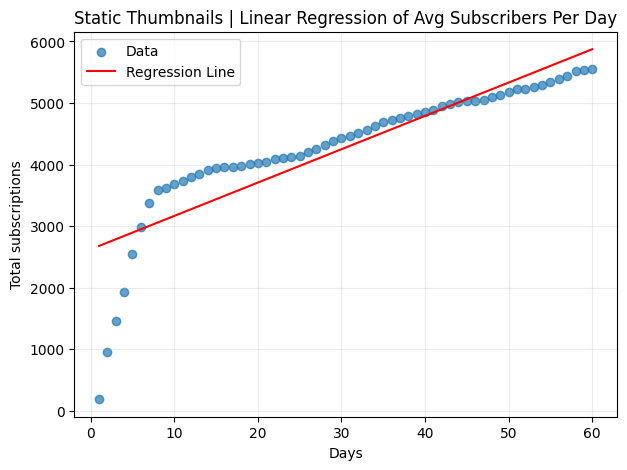

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(range(1,61), staticAvg, alpha=0.7, label="Data")
plt.title("Static Thumbnails | Linear Regression of Avg Subscribers Per Day")
plt.xlabel("Days")
plt.ylabel("Total subscriptions")

Xs = np.array(range(1,61)).reshape(-1,1) # need 2D array for linear regression

modelS = LinearRegression()
modelS.fit(Xs, staticAvg)

predS = modelS.predict(Xs)
plt.plot(Xs, predS, color="red", label="Regression Line")

plt.grid(alpha=0.25)
plt.legend()
plt.show()

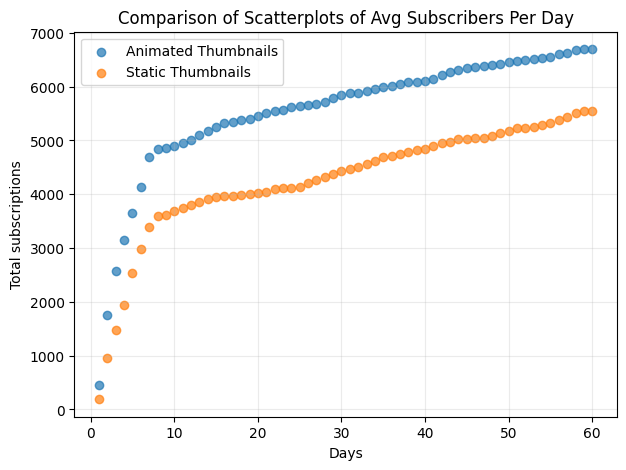

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(range(1,61), animatedAvg, alpha=0.7, label="Animated Thumbnails")
plt.scatter(range(1,61), staticAvg, alpha=0.7, label="Static Thumbnails")
plt.title("Comparison of Scatterplots of Avg Subscribers Per Day")
plt.xlabel("Days")
plt.ylabel("Total subscriptions")

plt.grid(alpha=0.25)
plt.legend()
plt.show()

Now let's combine the two lines:

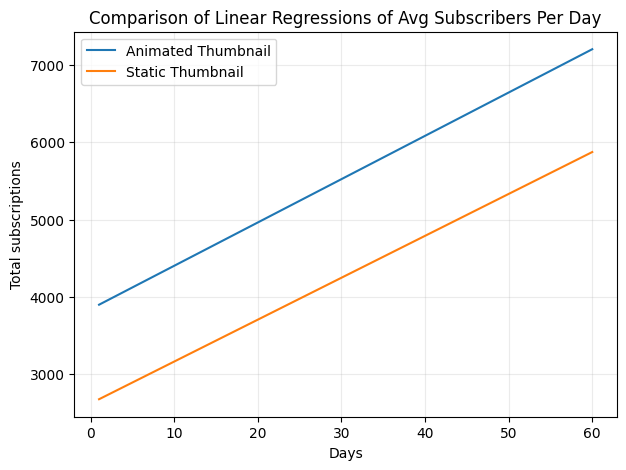

In [ ]:
plt.figure(figsize=(7, 5))
plt.title("Comparison of Linear Regressions of Avg Subscribers Per Day")
plt.xlabel("Days")
plt.ylabel("Total subscriptions")

plt.plot(Xa, predA, label="Animated Thumbnail")
plt.plot(Xs, predS, label="Static Thumbnail")

plt.grid(alpha=0.25)
plt.legend()
plt.show()

Nice result. The animated thumbnail linear regression is slightly higher than that of static thumbnails. We can say that mods that have animated thumbnails start with more subscribers but shows a similar increase pattern with static thumbnails. Though this is only just linear regression, and does not fit that well into our data, which means we could very well perform polynomial regression here.